In [6]:
import pandas as pd 
import numpy as np

from os.path import join
import os
from tqdm import tqdm
import pandas as pd
import numpy as np


pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', 10)
from IPython.display import HTML, display
css_style = """
<style>
.scrollable {
    max-height: 1000px; 
    overflow-y: auto;
    position: relative;
}

/* Make the table header sticky */
.scrollable thead th {
    position: sticky;
    top: 0;
    background: rgba(100, 100, 100, 100); 
    z-index: 1;
}


::-webkit-scrollbar {
    -webkit-appearance: none;
}

::-webkit-scrollbar:vertical {
    width: 12px;
}

::-webkit-scrollbar-thumb {
    background-color: rgba(0, 0, 0, .5);
    border-radius: 10px;
    border: 2px solid #ffffff;
}
</style>
"""

def show(df):
    html = css_style + df.to_html(border=0)
    display(HTML('<div class="scrollable">' + html + '</div>'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import numpy as np
import pandas as pd
import scipy.stats
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, recall_score, confusion_matrix
import torch
import re

def nice_plot_settings(font_size=14, font_family='STIXGeneral', mathtext_fontset='stix', usetex=False):
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 8))
    matplotlib.rcParams['mathtext.fontset'] = mathtext_fontset
    matplotlib.rcParams['font.family'] = font_family
    matplotlib.rcParams['text.usetex'] = usetex
    matplotlib.rcParams['font.size'] = font_size
    matplotlib.rcParams['axes.labelweight'] = 'bold'
    matplotlib.rcParams['axes.labelcolor'] = 'black'
    matplotlib.rcParams['axes.labelsize'] = font_size + 2
    matplotlib.rcParams['axes.titlesize'] = 'x-large'
    matplotlib.rcParams['axes.titleweight'] = 'bold'
    matplotlib.rcParams['axes.titlecolor'] = 'black'
    matplotlib.rcParams['xtick.color'] = 'black'
    matplotlib.rcParams['ytick.color'] = 'black'
    matplotlib.rcParams['legend.fontsize'] = 'medium'

nice_plot_settings()

newl = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/pivotedlabels.csv')

clinical_data = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/clinical_data/verosdata.csv')
clinical_data['taille_m'] = clinical_data['taille_cm'] / 100
clinical_data['bmi'] = clinical_data['poids_kg'] / (clinical_data['taille_m'] ** 2)
clinical_data['bmi'] = (clinical_data['bmi'] > 18.5).astype(int)
clinical_data['age'] = (clinical_data['age'] > 50).astype(int)
clinical_data['hiv_test_confirm'].fillna(1)
#clinical_data['record_id'] = clinical_data['record_id'].str.split('-').str[1].astype(int)
#clinical_data.index = clinical_data['indices']

symptoms = ['record_id','chief_complaint','accompanying_symptoms___6', 'accompanying_symptoms___5',
        'accompanying_symptoms___7',  'previous_tb_diagnosis', 'sexe','bmi', 'age', 'hiv_test_confirm',
            'quick_sofa_score']
d = clinical_data[symptoms]
#show(d)
lus_interpretations = clinical_data[['record_id', 'lus_qasd_1_final',
 'lus_qasd_2_final',
 'lus_qaid_1_final',
 'lus_qsld_2_final',
 'lus_qld_1_final',
 'lus_qasg_1_final',
 'lus_qasg_2_final',
 'lus_qaig_1_final',
 'lus_qslg_2_final',
 'lus_qlg_1_final',
 'lus_qpsd_1_final',
 'lus_qpid_1_final',
 'lus_qpsg_1_final',
 'lus_qpig_1_final']]

def extract_number(tensor_str):
    # Extract the number using a regular expression
    match = re.search(r'\d+', tensor_str)
    if match:
        return match.group(0)
    return tensor_str  # If no match is found, return the original string (just in case)



#ml_results = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/random_forest_featureselectionresults2.csv')
ml_results = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/mlresults3.csv')
ai_results = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Fold4unfrozen_testpredictions.csv')
ai_mlresults = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/aiml_randomforestresults3.csv')
clin_results = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clin_randomforestresults2.csv')
#ai_results = pd.read_csv('/home/tjb76/TBLUScopy/deepchest/predictions/TB4_testpredictions.csv')
ai_results['indices'] = '25-' + ai_results['indices'].apply(extract_number)
ai_results = ai_results[['indices', 'targets', 'predictions_proba']]
ai_results.columns = ['record_id', 'CAD LUS4TB_y', 'CAD LUS4TB_preds']


ml_model_name = 'Random Forest'
ml_results = ml_results[['record_id', 'y_test', f'{ml_model_name}_pred_proba']]
ml_results.columns = ['record_id', 'Human LUS - ML_y', 'Human LUS - ML_preds']

aiml_results = ai_mlresults[['record_id', 'y_test', f'{ml_model_name}_pred_proba']]
aiml_results.columns = ['record_id', 'AI LUS - ML_y', 'AI LUS - ML_preds']

ml_model_name = 'Random Forest'
clin_results = clin_results[['record_id', 'y_test', f'{ml_model_name}_pred_proba']]
clin_results.columns = ['record_id', 'Clinical Data_y', 'Clinical Data_preds']


preds = pd.merge(ai_results, ml_results, how='outer', left_on='record_id', right_on='record_id')
preds = pd.merge(preds, aiml_results, how='outer', left_on='record_id', right_on='record_id' )
preds = pd.merge(preds, clin_results, how='outer', left_on='record_id', right_on='record_id' )

preds['ULTR-AI ensemble_y'] = preds['CAD LUS4TB_y']
preds['ULTR-AI ensemble_preds'] = np.maximum(preds['CAD LUS4TB_preds'], preds['AI LUS - ML_preds'])
#preds['ULTR-AI ensemble_preds'] = np.median(np.stack((preds['CAD LUS4TB_preds'], preds['AI LUS - ML_preds']), axis=0), axis=0)


preds

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,AI LUS - ML_preds,Clinical Data_y,Clinical Data_preds,ULTR-AI ensemble_y,ULTR-AI ensemble_preds
0,25-103,1.0,0.767075,1,0.451406,1,0.377084,1,0.514117,1.0,0.767075
1,25-106,1.0,0.498474,1,0.180751,1,0.346681,1,0.688404,1.0,0.498474
2,25-108,1.0,0.116010,1,0.765050,1,0.371097,1,0.717559,1.0,0.371097
3,25-120,1.0,0.913574,1,0.181994,1,0.298428,1,0.354464,1.0,0.913574
4,25-128,0.0,0.051657,0,0.368262,0,0.221306,0,0.252943,0.0,0.221306
...,...,...,...,...,...,...,...,...,...,...,...
96,25-80,0.0,0.115347,0,0.250223,0,0.198493,0,0.653889,0.0,0.198493
97,25-82,1.0,0.941021,1,0.569347,1,0.344260,1,0.291237,1.0,0.941021
98,25-87,0.0,0.062701,0,0.197566,0,0.302475,0,0.143602,0.0,0.302475
99,25-9,0.0,0.043248,0,0.042310,0,0.221549,0,0.073422,0.0,0.221549


<Figure size 1000x800 with 0 Axes>

In [7]:
d

,record_id,chief_complaint,accompanying_symptoms___6,accompanying_symptoms___5,accompanying_symptoms___7,previous_tb_diagnosis,sexe,bmi,age,hiv_test_confirm,quick_sofa_score
0,25-1,2,0,0,1,1,1,1,0,NaN,0
1,25-4,2,1,0,0,1,1,0,0,NaN,1
2,25-5,2,1,0,0,1,1,0,0,NaN,2
3,25-7,2,0,0,0,1,1,1,0,NaN,1
4,25-9,2,0,0,0,2,2,1,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
499,25-759,2,1,0,1,1,1,1,0,2.0,1
500,25-760,2,1,0,0,1,2,0,1,NaN,1
501,25-761,2,1,0,0,1,2,0,0,NaN,1
502,25-762,2,1,0,1,1,2,0,0,NaN,1


In [3]:
show(preds)

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,AI LUS - ML_preds,Clinical Data_y,Clinical Data_preds,ULTR-AI ensemble_y,ULTR-AI ensemble_preds
0,25-103,1.0,0.767075,1,0.269368,1,0.377084,1,0.514117,1.0,0.767075
1,25-106,1.0,0.498474,1,0.274912,1,0.346681,1,0.688404,1.0,0.498474
2,25-108,1.0,0.116010,1,0.615626,1,0.371097,1,0.717559,1.0,0.371097
3,25-120,1.0,0.913574,1,0.270835,1,0.298428,1,0.354464,1.0,0.913574
4,25-128,0.0,0.051657,0,0.312858,0,0.221306,0,0.252943,0.0,0.221306
5,25-137,1.0,0.391585,1,0.169793,1,0.375191,1,0.558548,1.0,0.391585
6,25-144,0.0,0.032440,0,0.112003,0,0.075420,0,0.090460,0.0,0.075420
7,25-147,0.0,0.687394,0,0.451160,0,0.446830,0,0.213609,0.0,0.687394
8,25-149,0.0,0.080755,0,0.263770,0,0.114901,0,0.149965,0.0,0.114901
9,25-152,0.0,0.566121,0,0.627720,0,0.654786,0,0.763058,0.0,0.654786


In [8]:
preds['CombinedPredictions'] = np.maximum(preds['CAD LUS4TB_preds'], preds['AI LUS - ML_preds'])

from sklearn.metrics import roc_auc_score, f1_score
# auroc_cad = roc_auc_score(preds['CAD LUS4TB_y'], preds['CAD LUS4TB_preds'])
# auroc_ai = roc_auc_score(preds['CAD LUS4TB_y'], preds['AI LUS - ML_preds'])
# auroc_combined = roc_auc_score(preds['CAD LUS4TB_y'], preds['CombinedPredictions'])

auroc_cad = f1_score(preds['CAD LUS4TB_y'], preds['CAD LUS4TB_preds'])
auroc_ai = f1_score(preds['CAD LUS4TB_y'], preds['AI LUS - ML_preds'])
auroc_combined = f1_score(preds['CAD LUS4TB_y'], preds['CombinedPredictions'])


auroc_results = {
    'CAD LUS4TB_preds AUROC': auroc_cad,
    'AI LUS - ML_preds AUROC': auroc_ai,
    'CombinedPredictions AUROC': auroc_combined
}
auroc_results

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = preds[['CAD LUS4TB_preds', 'AI LUS - ML_preds']]
y = preds['CAD LUS4TB_y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]  

logreg_auroc = roc_auc_score(y_test, y_pred_proba)
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

model_coefficients = log_reg.coef_
model_intercept = log_reg.intercept_

results = {
    'Test AUROC': logreg_auroc,
    'Test Accuracy': accuracy,
    'Model Coefficients': model_coefficients,
    'Model Intercept': model_intercept
}

results

{'Test AUROC': 0.9903846153846154,
 'Test Accuracy': 0.9047619047619048,
 'Model Coefficients': array([[2.86920264, 1.49149116]]),
 'Model Intercept': array([-2.03138751])}

In [3]:
f = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/videodf.csv')
f = f.dropna(subset=['Large Consolidations'])
f

,Unnamed: 0,record_id,site,TB Label,A-lines,B-lines,3 B-lines,Coalescing B-lines,Ordinal_A_B-lines,Consolidations and nodules,Small consolidations and or nodules,Large Consolidations,Ordinal_consolidations,Pattern A (pneumothorax),Pleural effusion,count,path
2,2,25-1,APXD,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
3,3,25-1,APXD,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
4,4,25-1,APXD,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
5,5,25-1,APXG,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
6,6,25-1,APXG,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13686,13686,25-98,QPSG,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
13687,13687,25-98,QPSG,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
13688,13688,25-98,QSLD,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...
13689,13689,25-98,QSLD,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/...


In [2]:
preds

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,AI LUS - ML_preds,Clinical Data_y,Clinical Data_preds
0,25-103,1.0,0.767075,1,0.269368,1,0.377084,1,0.514117
1,25-106,1.0,0.498474,1,0.274912,1,0.346681,1,0.688404
2,25-108,1.0,0.116010,1,0.615626,1,0.371097,1,0.717559
3,25-120,1.0,0.913574,1,0.270835,1,0.298428,1,0.354464
4,25-128,0.0,0.051657,0,0.312858,0,0.221306,0,0.252943
...,...,...,...,...,...,...,...,...,...
96,25-80,0.0,0.115347,0,0.314118,0,0.198493,0,0.653889
97,25-82,1.0,0.941021,1,0.536193,1,0.344260,1,0.291237
98,25-87,0.0,0.062701,0,0.285057,0,0.302475,0,0.143602
99,25-9,0.0,0.043248,0,0.098645,0,0.221549,0,0.073422


In [10]:
s = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/Labels/Benin/expertimagedf.csv')
s['record_id'].value_counts().describe()

count    505.000000
mean      26.942574
std        2.594001
min       14.000000
25%       27.000000
50%       28.000000
75%       28.000000
max       35.000000
Name: count, dtype: float64

In [7]:
# ai_results = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/Fold_0_testpredictions.csv')
# ai_results['indices'] = '25-' + ai_results['indices'].astype(str)
# testfoldspreds2 = pd.DataFrame()
# testfoldspreds2['record_id'] = ai_results['indices']
# testfoldspreds2['TB Label'] = ai_results['targets']
# dir = '/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/'
# ind = [0,1,2,3,4]
# for i, numb in enumerate(ind):
#     df = pd.read_csv(f'/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/Fold_{numb}_testpredictions.csv')
#     testfoldspreds2[f'CAD LUS4TB_Fold_{i}'] = df['predictions_proba']
# testfoldspreds2.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')

In [36]:
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')

t = aiml_folds_preds[['record_id', 'TB Label', 'Random Forest_Fold_0','Random Forest_Fold_1', 'Random Forest_Fold_2', 'Random Forest_Fold_3', 'Random Forest_Fold_4' ]]

def convert_string(s):
    # This will replace 'tensor(' and ')' with empty strings
    return s.replace('tensor(', '').replace(')', '')
ai_folds_preds['record_id'] = ai_folds_preds['record_id'].apply(convert_string)
ai_folds_preds.columns
f = ai_folds_preds[['record_id', 'TB Label', 'CAD LUS4TB_Fold_0',
       'CAD LUS4TB_Fold_1', 'CAD LUS4TB_Fold_2', 'CAD LUS4TB_Fold_3',
       'CAD LUS4TB_Fold_4']]
df = pd.merge(f, t, left_on='record_id', right_on='record_id')
max_predictions = pd.DataFrame()

# Copy over the 'record_id' and 'TB Label_y'
max_predictions['record_id'] = df['record_id']
max_predictions['TB Label'] = df['TB Label_y']

# Iterate over each fold and take the element-wise max of CAD LUS4TB and Random Forest
for i in range(5):  # Assuming there are 5 folds
    max_predictions[f'Max_Fold_{i}'] = df[[f'CAD LUS4TB_Fold_{i}', f'Random Forest_Fold_{i}']].max(axis=1)

# Display the new DataFrame with max predictions
max_predictions
#max_predictions.to_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')

In [3]:
ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
clin_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clinFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h


def calc_confidence_interval(df, model_name, name, threshold=0.5):
    folds = [0, 1, 2, 3, 4]
    test_aurocs = []
    test_accuracies = []
    test_balanced_accuracies = []
    test_sensitivity = []
    test_specificity = []
    test_positive_likelihood_ratio = []
    test_negative_likelihood_ratio = []
    test_fpr = []
    test_fnr = []
    test_f1 = []

    
    
    for f in folds:
        # Calculate metrics
        true_labels = df['TB Label']
        preds = df[f'{model_name}_Fold_{f}'] > threshold
        
        test_aurocs.append(roc_auc_score(true_labels, df[f'{model_name}_Fold_{f}']))
        test_accuracies.append(accuracy_score(true_labels, preds))
        test_balanced_accuracies.append(balanced_accuracy_score(true_labels, preds))
        
        tn, fp, fn, tp = confusion_matrix(true_labels, preds).ravel()
        sensitivity = recall_score(true_labels, preds)
        specificity = tn / (tn + fp)
        
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        f1 = f1_score(true_labels, preds)
        
        test_sensitivity.append(sensitivity)
        test_specificity.append(specificity)
        test_positive_likelihood_ratio.append(sensitivity / (1 - specificity))
        test_negative_likelihood_ratio.append((1 - sensitivity) / specificity)
        test_fpr.append(fpr)
        test_fnr.append(fnr)
        test_f1.append(f1)
    
    print(test_aurocs)
    mean_auc, ci_auc_lower, ci_auc_upper = mean_confidence_interval(test_aurocs)
    mean_acc, ci_acc_lower, ci_acc_upper = mean_confidence_interval(test_accuracies)
    mean_bal_acc, ci_bal_acc_lower, ci_bal_acc_upper = mean_confidence_interval(test_balanced_accuracies)
    mean_sens, ci_sens_lower, ci_sens_upper = mean_confidence_interval(test_sensitivity)
    mean_spec, ci_spec_lower, ci_spec_upper = mean_confidence_interval(test_specificity)
    mean_plr, ci_plr_lower, ci_plr_upper = mean_confidence_interval(test_positive_likelihood_ratio)
    mean_nlr, ci_nlr_lower, ci_nlr_upper = mean_confidence_interval(test_negative_likelihood_ratio)
    mean_fpr, ci_fpr_lower, ci_fpr_upper = mean_confidence_interval(test_fpr)
    mean_fnr, ci_fnr_lower, ci_fnr_upper = mean_confidence_interval(test_fnr)
    mean_f1, ci_f1_lower, ci_f1_upper = mean_confidence_interval(test_f1)

    results = {
        f'{name}_AUROC': (mean_auc, ci_auc_lower, ci_auc_upper),
        f'{name}_Accuracy': (mean_acc, ci_acc_lower, ci_acc_upper),
        f'{name}_Balanced Accuracy': (mean_bal_acc, ci_bal_acc_lower, ci_bal_acc_upper),
        f'{name}_Sensitivity': (mean_sens, ci_sens_lower, ci_sens_upper),
        f'{name}_Specificity': (mean_spec, ci_spec_lower, ci_spec_upper),
        f'{name}_Positive Likelihood Ratio': (mean_plr, ci_plr_lower, ci_plr_upper),
        f'{name}_Negative Likelihood Ratio': (mean_nlr, ci_nlr_lower, ci_nlr_upper),
        f'{name}_FPR': (mean_fpr, ci_fpr_lower, ci_fpr_upper),
        f'{name}_FNR': (mean_fnr, ci_fnr_lower, ci_fnr_upper),
        f'{name}_F1': (mean_f1, ci_f1_lower, ci_f1_upper),

        
    }
    results_df = pd.DataFrame(results, index=['Mean', 'Lower CI', 'Upper CI']).T.reset_index().rename(columns={'index': 'Metric'})
    results_df['Model'] = results_df['Metric'].str.split('_').str[0]
    results_df['Metric'] = results_df['Metric'].str.split('_').str[1]
    results_df = results_df[['Model', 'Metric','Mean', 'Lower CI', 'Upper CI']]
    return results_df

ai_results = calc_confidence_interval(ai_folds_preds, 'CAD LUS4TB', 'CAD LUS4TB')
ml_results = calc_confidence_interval(ml_folds_preds, 'Random Forest', 'Human LUS - ML')
aiml_results = calc_confidence_interval(aiml_folds_preds, 'Random Forest', 'AI LUS - ML')
clin_results = calc_confidence_interval(clin_folds_preds, 'XGBoost', 'Clinical Data')
max_results = calc_confidence_interval(max_folds_preds, 'Max', 'ULTR-AI ensemble')
metrics_results = pd.concat([ai_results, ml_results, aiml_results, clin_results, max_results])
show(metrics_results)    

[0.9139515455304928, 0.8897243107769424, 0.8976608187134504, 0.9122807017543859, 0.934001670843776]
[0.8253968253968254, 0.8471177944862155, 0.8370927318295739, 0.8458646616541353, 0.8379281537176273]
[0.887218045112782, 0.9076858813700919, 0.8817878028404345, 0.9089390142021722, 0.9051796157059315]
[0.8395989974937343, 0.8575605680868839, 0.8717627401837929, 0.8721804511278196, 0.8504594820384294]
[0.9289891395154553, 0.9273182957393483, 0.9256474519632414, 0.9243943191311613, 0.951545530492899]


,Model,Metric,Mean,Lower CI,Upper CI
0,CAD LUS4TB,AUROC,0.909524,0.888387,0.930661
1,CAD LUS4TB,Accuracy,0.835644,0.808709,0.862578
2,CAD LUS4TB,Balanced Accuracy,0.817084,0.777539,0.856630
3,CAD LUS4TB,Sensitivity,0.742105,0.640338,0.843872
4,CAD LUS4TB,Specificity,0.892063,0.854153,0.929974
5,CAD LUS4TB,Positive Likelihood Ratio,7.300000,4.741355,9.858645
6,CAD LUS4TB,Negative Likelihood Ratio,0.287557,0.180666,0.394448
7,CAD LUS4TB,FPR,0.107937,0.070026,0.145847
8,CAD LUS4TB,FNR,0.257895,0.156128,0.359662
9,CAD LUS4TB,F1,0.770988,0.721374,0.820602


In [10]:
import numpy as np
from sklearn.metrics import recall_score, accuracy_score, balanced_accuracy_score, confusion_matrix, roc_auc_score

import numpy as np
from sklearn.metrics import recall_score, confusion_matrix

# def find_optimal_threshold(df, model_name, target_sensitivity=0.9, min_specificity=0.6):
#     folds = [0, 1, 2, 3, 4]
#     thresholds = np.linspace(0, 1, 100)  # Test thresholds between 0 and 1
#     best_threshold = None
#     best_mean_sensitivity = 0
#     best_specificity = 0
    
#     for threshold in thresholds:
#         sensitivities = []
#         specificities = []
        
#         for f in folds:
#             # true_labels = df['TB Label']
#             # preds = (df[f'{model_name}_Fold_{f}'] > threshold).astype(int)
            
#             # tn, fp, fn, tp = confusion_matrix(true_labels, preds).ravel()
#             # sensitivity = recall_score(true_labels, preds)
#             # specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
#             y_true = df['TB Label']
#             y_pred = df[f'{model_name}_Fold_{f}']
            
#             fpr, tpr, thresholds = roc_curve(y_true, y_pred)
#             tpr_interp = np.interp(mean_fpr, fpr, tpr)
            
#             # Apply interpolated thresholds
#             for threshold in np.linspace(0, 1, 100):
#                 preds = (y_pred > threshold).astype(int)
#                 tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
#                 sensitivity = recall_score(y_true, preds)
#                 specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
#             sensitivities.append(sensitivity)
#             specificities.append(specificity)
        
#         mean_sensitivity = np.mean(sensitivities)
#         mean_specificity = np.mean(specificities)
        
#         # Update the threshold only if mean sensitivity is >= target sensitivity and specificity is better than best found so far
#         if mean_sensitivity >= target_sensitivity and mean_specificity > best_specificity:
#             best_threshold = threshold
#             best_mean_sensitivity = mean_sensitivity
#             best_specificity = mean_specificity
    
#     return best_threshold, best_mean_sensitivity, best_specificity
# import numpy as np
# from sklearn.metrics import recall_score, confusion_matrix

import numpy as np
from sklearn.metrics import recall_score, confusion_matrix, roc_curve, auc

import numpy as np
from sklearn.metrics import recall_score, confusion_matrix, roc_curve, auc

def find_optimal_threshold(df, model_name, target_sensitivity=0.9, min_specificity=0.7):
    folds = [0, 1, 2, 3, 4]
    best_threshold = None
    best_mean_sensitivity = 0
    best_specificity = 0

    # Store sensitivities, specificities, and thresholds for all folds
    all_thresholds = []
    all_sensitivities = []
    all_specificities = []

    # First pass: Gather thresholds, sensitivities, and specificities from each fold
    for f in folds:
        y_true = df['TB Label']
        y_pred = df[f'{model_name}_Fold_{f}']

        # Get ROC curve values
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        
        # Store the thresholds for this fold
        all_thresholds.extend(thresholds)

        # Calculate sensitivity and specificity at each threshold
        for i, threshold in enumerate(thresholds):
            preds = (y_pred >= threshold).astype(int)  # Ensure correct thresholding

            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            all_sensitivities.append(sensitivity)
            all_specificities.append(specificity)

    # Second pass: Iterate over unique thresholds to find the optimal one
    for threshold in np.unique(all_thresholds):
        sensitivities = []
        specificities = []

        for f in folds:
            y_true = df['TB Label']
            y_pred = df[f'{model_name}_Fold_{f}']

            # Apply threshold to predictions
            preds = (y_pred >= threshold).astype(int)

            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            sensitivities.append(sensitivity)
            specificities.append(specificity)

        mean_sensitivity = np.mean(sensitivities)
        mean_specificity = np.mean(specificities)

        # Update the best threshold if it meets the criteria
        if mean_sensitivity >= target_sensitivity and mean_specificity > best_specificity:
            best_threshold = threshold
            best_mean_sensitivity = mean_sensitivity
            best_specificity = mean_specificity

    return best_threshold, best_mean_sensitivity, best_specificity

# def find_optimal_threshold(df, model_name, target_sensitivity=0.9, target_specificity=0.7):
#     folds = [0, 1, 2, 3, 4]
#     thresholds = np.linspace(0, 1, 100)  # Test thresholds between 0 and 1
#     best_threshold = None
#     best_mean_sensitivity = 0
#     best_mean_specificity = 0
#     closest_threshold = None
#     closest_sensitivity = 0
#     closest_specificity = 0
    
#     for threshold in thresholds:
#         sensitivities = []
#         specificities = []
        
#         for f in folds:
#             true_labels = df['TB Label']
#             preds = (df[f'{model_name}_Fold_{f}'] > threshold).astype(int)
            
#             tn, fp, fn, tp = confusion_matrix(true_labels, preds).ravel()
#             sensitivity = recall_score(true_labels, preds)
#             specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
#             sensitivities.append(sensitivity)
#             specificities.append(specificity)
        
#         mean_sensitivity = np.mean(sensitivities)
#         mean_specificity = np.mean(specificities)
        
#         # Select the best threshold where both sensitivity and specificity criteria are met
#         if mean_sensitivity >= target_sensitivity and mean_specificity >= target_specificity:
#             best_threshold = threshold
#             best_mean_sensitivity = mean_sensitivity
#             best_mean_specificity = mean_specificity
#             break  # Stop once we meet both target sensitivity and specificity
        
#         # If we can't find a threshold that satisfies both, keep track of the closest match
#         if mean_sensitivity >= target_sensitivity and mean_specificity > closest_specificity:
#             closest_threshold = threshold
#             closest_sensitivity = mean_sensitivity
#             closest_specificity = mean_specificity

#     # If we never meet both criteria, return the closest one
#     if best_threshold is None:
#         return closest_threshold, closest_sensitivity, closest_specificity

#     return best_threshold, best_mean_sensitivity, best_mean_specificity

# Apply the function to each model
ai_threshold, ai_sensitivity, ai_specificity = find_optimal_threshold(ai_folds_preds, 'CAD LUS4TB')
ml_threshold, ml_sensitivity, ml_specificity = find_optimal_threshold(ml_folds_preds, 'Random Forest')
aiml_threshold, aiml_sensitivity, aiml_specificity = find_optimal_threshold(aiml_folds_preds, 'Random Forest')
clin_threshold, clin_sensitivity, clin_specificity = find_optimal_threshold(clin_folds_preds, 'XGBoost')
max_threshold, max_sensitivity, max_specificity = find_optimal_threshold(max_folds_preds, 'Max')

# Print or use the thresholds
print(f'AI Threshold: {ai_threshold}, Sensitivity: {ai_sensitivity}, Specificity: {ai_specificity}')
print(f'ML Threshold: {ml_threshold}, Sensitivity: {ml_sensitivity}, Specificity: {ml_specificity}')
print(f'AIML Threshold: {aiml_threshold}, Sensitivity: {aiml_sensitivity}, Specificity: {aiml_specificity}')
print(f'Clinical Threshold: {clin_threshold}, Sensitivity: {clin_sensitivity}, Specificity: {clin_specificity}')
print(f'Max Threshold: {max_threshold}, Sensitivity: {max_sensitivity}, Specificity: {max_specificity}')

AI Threshold: 0.20631184, Sensitivity: 0.9, Specificity: 0.6571428571428573
ML Threshold: 0.2225964140053746, Sensitivity: 0.9, Specificity: 0.5936507936507937
AIML Threshold: 0.2220215595286074, Sensitivity: 0.9, Specificity: 0.7047619047619047
Clinical Threshold: 0.22890414, Sensitivity: 0.9052631578947368, Specificity: 0.6507936507936508
Max Threshold: 0.39158458, Sensitivity: 0.9052631578947368, Specificity: 0.8317460317460318


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix
from scipy.stats import t

def calculate_interpolated_metrics(df, model_name, target_sensitivity=0.9):
    """Calculate metrics where sensitivity is fixed at 0.9 across folds."""
    folds = [0, 1, 2, 3, 4]
    mean_fpr = np.linspace(0, 1, 100)  # Standardized FPR range for interpolation
    aucs, results = [], []

    # Iterate over folds to calculate interpolated metrics
    for f in folds:
        y_true = df['TB Label']
        y_pred = df[f'{model_name}_Fold_{f}']

        # Compute ROC curve
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)

        # Interpolate TPR and thresholds over the standardized mean FPR range
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        thresholds_interp = np.interp(mean_fpr, fpr, thresholds)

        # Ensure the interpolated TPR starts at 0 and ends at 1
        tpr_interp[0] = 0.0
        tpr_interp[-1] = 1.0

        # Calculate AUC for this fold
        aucs.append(auc(fpr, tpr))

        # Calculate metrics at the sensitivity = 0.9 point
        result = calculate_metrics_at_sensitivity(f, thresholds_interp, tpr_interp, mean_fpr, target_sensitivity)
        results.append(result)

    # Aggregate results across folds
    aggregated_results = aggregate_results(results)
    aggregated_results['Mean_AUC'] = np.mean(aucs)
    aggregated_results['AUC_95%_CI'] = compute_ci_from_std(aucs)

    return aggregated_results

def calculate_metrics_at_sensitivity(fold, thresholds, tpr, fpr, target_sensitivity=0.9):
    """Find the threshold and calculate metrics closest to the target sensitivity (0.9)."""
    
    # Find the index with the closest sensitivity to the target
    idx = np.argmin(np.abs(tpr - target_sensitivity))  # Closest index to 0.9
    threshold = thresholds[idx]
    sensitivity = tpr[idx]
    specificity = 1 - fpr[idx]

    # Print debugging information
    print(f"Fold {fold}: Threshold={threshold:.4f}, Sensitivity={sensitivity:.4f}, Specificity={specificity:.4f}")

    # Calculate FPR and FNR
    fpr_value = fpr[idx]
    fnr_value = 1 - sensitivity  # FNR = 1 - Sensitivity

    # Calculate PLR and NLR
    plr = sensitivity / (1 - specificity) if (1 - specificity) > 0 else np.inf
    nlr = fnr_value / specificity if specificity > 0 else np.inf

    # Calculate accuracy
    accuracy = (sensitivity + specificity) / 2  # Approximate balanced accuracy

    return {
        'Fold': fold,
        'Threshold': threshold,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'FPR': fpr_value,
        'FNR': fnr_value,
        'PLR': plr,
        'NLR': nlr,
        'Accuracy': accuracy
    }
def aggregate_results(results):
    """Aggregate the metrics across all folds."""
    metrics = {key: [result[key] for result in results] for key in results[0]}

    aggregated = {
        'Mean_Sensitivity': np.mean(metrics['Sensitivity']),
        'Sensitivity_95%_CI': compute_ci_from_std(metrics['Sensitivity']),
        'Mean_Specificity': np.mean(metrics['Specificity']),
        'Specificity_95%_CI': compute_ci_from_std(metrics['Specificity']),
        'Mean_FPR': np.mean(metrics['FPR']),
        'FPR_95%_CI': compute_ci_from_std(metrics['FPR']),
        'Mean_FNR': np.mean(metrics['FNR']),
        'FNR_95%_CI': compute_ci_from_std(metrics['FNR']),
        'Mean_PLR': np.mean(metrics['PLR']),
        'PLR_95%_CI': compute_ci_from_std(metrics['PLR']),
        'Mean_NLR': np.mean(metrics['NLR']),
        'NLR_95%_CI': compute_ci_from_std(metrics['NLR']),
        'Accuracy': np.mean(metrics['Accuracy']),
        'Accuracy_95%_CI': compute_ci_from_std(metrics['Accuracy']),
        'Mean_Threshold': np.mean(metrics['Threshold']),
        'Threshold_95%_CI': compute_ci_from_std(metrics['Threshold'])
    }

    return aggregated

def compute_ci_from_std(data, confidence=0.95):
    """Compute 95% confidence interval using standard deviation."""
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)
    margin_of_error = std_err * t.ppf((1 + confidence) / 2, n - 1)
    return mean - margin_of_error, mean + margin_of_error

def generate_results_table(models_data):
    """Generate results table for multiple models."""
    results = []
    for final_name, [model_name, df] in models_data.items():
        model_results = calculate_interpolated_metrics(df, model_name)
        model_results['Model'] = final_name  # Add model name to results
        results.append(model_results)

    return pd.DataFrame(results)

# Example usage
ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
clin_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/clinFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')

models_data = {
    'ML folds': ['Random Forest', ml_folds_preds],
     'ULTR-AI': ['CAD LUS4TB', ai_folds_preds],
    'ULTR-AI [signs]': ['Random Forest', aiml_folds_preds],
    'ULTR-AI [max]': ['Max', max_folds_preds]
}

results_df = generate_results_table(models_data)
results_df

Fold 0: Threshold=0.1783, Sensitivity=0.8947, Specificity=0.5354
Fold 1: Threshold=0.1814, Sensitivity=0.9067, Specificity=0.5960
Fold 2: Threshold=0.2627, Sensitivity=0.8900, Specificity=0.5960
Fold 3: Threshold=0.2718, Sensitivity=0.9211, Specificity=0.6465
Fold 4: Threshold=0.2740, Sensitivity=0.8947, Specificity=0.6667
Fold 0: Threshold=0.2992, Sensitivity=0.8947, Specificity=0.7374
Fold 1: Threshold=0.2937, Sensitivity=0.8947, Specificity=0.6970
Fold 2: Threshold=0.1801, Sensitivity=0.8947, Specificity=0.7071
Fold 3: Threshold=0.2053, Sensitivity=0.8947, Specificity=0.8081
Fold 4: Threshold=0.1477, Sensitivity=0.8947, Specificity=0.8384
Fold 0: Threshold=0.2220, Sensitivity=0.8947, Specificity=0.6970
Fold 1: Threshold=0.3097, Sensitivity=0.8947, Specificity=0.8182
Fold 2: Threshold=0.1917, Sensitivity=0.8947, Specificity=0.6970
Fold 3: Threshold=0.2447, Sensitivity=0.9211, Specificity=0.7576
Fold 4: Threshold=0.2809, Sensitivity=0.8947, Specificity=0.8081
Fold 0: Threshold=0.4172,

,Mean_Sensitivity,Sensitivity_95%_CI,Mean_Specificity,Specificity_95%_CI,Mean_FPR,FPR_95%_CI,Mean_FNR,FNR_95%_CI,Mean_PLR,PLR_95%_CI,Mean_NLR,NLR_95%_CI,Accuracy,Accuracy_95%_CI,Mean_Threshold,Threshold_95%_CI,Mean_AUC,AUC_95%_CI,Model
0,0.901435,"(0.8858014936652719, 0.9170693197318572)",0.608081,"(0.5444986219479916, 0.6716629942136244)",0.391919,"(0.3283370057863756, 0.4555013780520083)",0.098565,"(0.08293068026814271, 0.11419850633472803)",2.332363,"(1.9454853214528676, 2.7192400790047984)",0.163571,"(0.1277096568524672, 0.19943165691724635)",0.754758,"(0.7194073506392649, 0.7901088641401077)",0.233665,"(0.172463234607653, 0.2948665574429566)",0.838680,"(0.827884995628649, 0.8494750712051017)",ML folds
1,0.894737,"(0.8947368421052632, 0.8947368421052632)",0.757576,"(0.6797543182036115, 0.8353971969479036)",0.242424,"(0.1646028030520964, 0.32024568179638846)",0.105263,"(0.10526315789473684, 0.10526315789473684)",3.922439,"(2.5189008030430813, 5.325977078173992)",0.139695,"(0.12566128054731257, 0.15372835275291308)",0.826156,"(0.7872455801544374, 0.8650670195265835)",0.225219,"(0.14052474863242648, 0.3099135416948462)",0.909524,"(0.8883870400403333, 0.9306605790072859)",ULTR-AI
2,0.900000,"(0.8853871310252748, 0.9146128689747253)",0.755556,"(0.6832889033440381, 0.8278222077670729)",0.244444,"(0.17217779223292695, 0.316711096655962)",0.100000,"(0.08538713102527476, 0.11461286897472525)",3.857542,"(2.709522504626072, 5.005560597867001)",0.133038,"(0.10895014923731473, 0.15712511137799168)",0.827778,"(0.790774444797759, 0.8647811107577964)",0.249804,"(0.19179374991694154, 0.30781445509115385)",0.898162,"(0.8824073694710077, 0.9139167742215573)",ULTR-AI [signs]
3,0.905263,"(0.887366121561625, 0.923160194227849)",0.854545,"(0.811462061587918, 0.8976288475029914)",0.145455,"(0.10237115249700875, 0.18853793841208222)",0.094737,"(0.07683980577215116, 0.11263387843837516)",6.516544,"(4.574323104870375, 8.4587655377889)",0.110910,"(0.09025803787416688, 0.13156164687988692)",0.879904,"(0.8579350504958092, 0.9018735619443821)",0.434761,"(0.3336385492624956, 0.5358844271640312)",0.931579,"(0.9175541035276674, 0.9456037912091747)",ULTR-AI [max]


In [4]:
ai_results = calc_confidence_interval(ai_folds_preds, 'CAD LUS4TB', 'CAD LUS4TB', threshold=0.202)
ml_results = calc_confidence_interval(ml_folds_preds, 'Random Forest', 'Human LUS - ML', threshold=0.222)
aiml_results = calc_confidence_interval(aiml_folds_preds, 'Random Forest', 'AI LUS - ML', threshold=0.2121)
#clin_results = calc_confidence_interval(clin_folds_preds, 'XGBoost', 'Clinical Data', threshold=0.222)
max_results = calc_confidence_interval(max_folds_preds, 'Max', 'ULTR-AI ensemble', threshold=0.36)
m_results = pd.concat([ai_results, ml_results, aiml_results, max_results])


thresholds = [0.20, 0.22, 0.21, 0.38]
show(m_results)    

[0.9139515455304928, 0.8897243107769424, 0.8976608187134504, 0.9122807017543859, 0.934001670843776]
[0.8253968253968254, 0.8471177944862155, 0.8370927318295739, 0.8458646616541353, 0.8379281537176273]
[0.887218045112782, 0.9076858813700919, 0.8817878028404345, 0.9089390142021722, 0.9051796157059315]
[0.9289891395154553, 0.9273182957393483, 0.9256474519632414, 0.9243943191311613, 0.951545530492899]


,Model,Metric,Mean,Lower CI,Upper CI
0,CAD LUS4TB,AUROC,0.909524,0.888387,0.930661
1,CAD LUS4TB,Accuracy,0.740594,0.538513,0.942675
2,CAD LUS4TB,Balanced Accuracy,0.772222,0.618492,0.925952
3,CAD LUS4TB,Sensitivity,0.900000,0.841549,0.958451
4,CAD LUS4TB,Specificity,0.644444,0.293924,0.994965
5,CAD LUS4TB,Positive Likelihood Ratio,3.660121,1.233496,6.086747
6,CAD LUS4TB,Negative Likelihood Ratio,0.174708,0.073962,0.275454
7,CAD LUS4TB,FPR,0.355556,0.005035,0.706076
8,CAD LUS4TB,FNR,0.100000,0.041549,0.158451
9,CAD LUS4TB,F1,0.739407,0.612418,0.866397


In [56]:
ai_results = calc_confidence_interval(ai_folds_preds, 'CAD LUS4TB', 'CAD LUS4TB', threshold=0.225)
ml_results = calc_confidence_interval(ml_folds_preds, 'Random Forest', 'Human LUS - ML', threshold=0.2)
aiml_results = calc_confidence_interval(aiml_folds_preds, 'Random Forest', 'AI LUS - ML', threshold=0.22)
#clin_results = calc_confidence_interval(clin_folds_preds, 'XGBoost', 'Clinical Data', threshold=0.222)
max_results = calc_confidence_interval(max_folds_preds, 'Max', 'ULTR-AI ensemble', threshold=0.36)
m_results = pd.concat([ai_results, ml_results, aiml_results, max_results])


thresholds = [0.20, 0.22, 0.21, 0.38]
show(m_results)    

[0.9139515455304928, 0.8897243107769424, 0.8976608187134504, 0.9122807017543859, 0.934001670843776]
[0.8253968253968254, 0.8471177944862155, 0.8370927318295739, 0.8458646616541353, 0.8379281537176273]
[0.887218045112782, 0.9076858813700919, 0.8817878028404345, 0.9089390142021722, 0.9051796157059315]
[0.9289891395154553, 0.9273182957393483, 0.9256474519632414, 0.9243943191311613, 0.951545530492899]


,Model,Metric,Mean,Lower CI,Upper CI
0,CAD LUS4TB,AUROC,0.909524,0.888387,0.930661
1,CAD LUS4TB,Accuracy,0.764356,0.627074,0.901639
2,CAD LUS4TB,Balanced Accuracy,0.788137,0.688550,0.887724
3,CAD LUS4TB,Sensitivity,0.884211,0.808986,0.959435
4,CAD LUS4TB,Specificity,0.692063,0.436758,0.947369
5,CAD LUS4TB,Positive Likelihood Ratio,3.836326,1.307573,6.365079
6,CAD LUS4TB,Negative Likelihood Ratio,0.161281,0.093184,0.229378
7,CAD LUS4TB,FPR,0.307937,0.052631,0.563242
8,CAD LUS4TB,FNR,0.115789,0.040565,0.191014
0,Human LUS - ML,AUROC,0.838680,0.827885,0.849475


In [23]:
df = m_results
df['95% CI'] = df.apply(lambda row: f"({row['Lower CI']:.2f} - {row['Upper CI']:.2f})", axis=1)
thresholds = [0.20, 0.22, 0.21, 0.38]  # The thresholds f
# Step 2: Round the mean metric to two decimal places
thresholds = [0.20, 0.22, 0.21, 0.38]  # The thresholds for each model
models = df['Model'].unique()  # Get unique model names to match thresholds
thresholds_df = pd.DataFrame({'Model': models, 'Threshold': thresholds})

# Step 2: Create the 95% CI column
df['95% CI'] = df.apply(lambda row: f"({row['Lower CI']:.2f}, {row['Upper CI']:.2f})", axis=1)

# Step 3: Round the mean metric to two decimal places
df['Mean'] = df['Mean'].round(2)

# Step 4: Pivot the table
pivoted_df = df.pivot(index='Model', columns='Metric', values=['Mean', '95% CI'])

# Step 5: Flatten the multi-level columns
pivoted_df.columns = [f'{metric}_{col}' for col, metric in pivoted_df.columns]

# Step 6: Reorder the columns so that 'Mean' is followed by '95% CI' for each metric
metrics = sorted(set(col.split('_')[0] for col in pivoted_df.columns))
ordered_columns = [col for metric in metrics for col in [f'{metric}_Mean', f'{metric}_95% CI']]

# Reorder the columns in the DataFrame
pivoted_df = pivoted_df[ordered_columns]

# Step 7: Merge the thresholds into the pivoted DataFrame
pivoted_df = pd.merge(thresholds_df, pivoted_df, on='Model')

# Display the final DataFrame
pivoted_df

# If
pivoted_df.to_csv('MetricsAtThreshold.csv')
pivoted_df

,Model,Threshold,AUROC_Mean,AUROC_95% CI,Accuracy_Mean,Accuracy_95% CI,Balanced Accuracy_Mean,Balanced Accuracy_95% CI,FNR_Mean,FNR_95% CI,FPR_Mean,FPR_95% CI,Negative Likelihood Ratio_Mean,Negative Likelihood Ratio_95% CI,Positive Likelihood Ratio_Mean,Positive Likelihood Ratio_95% CI,Sensitivity_Mean,Sensitivity_95% CI,Specificity_Mean,Specificity_95% CI
0,CAD LUS4TB,0.20,0.91,"(0.89, 0.93)",0.74,"(0.54, 0.94)",0.77,"(0.62, 0.93)",0.1,"(0.04, 0.16)",0.36,"(0.01, 0.71)",0.17,"(0.07, 0.28)",3.66,"(1.23, 6.09)",0.9,"(0.84, 0.96)",0.64,"(0.29, 0.99)"
1,Human LUS - ML,0.22,0.84,"(0.83, 0.86)",0.71,"(0.68, 0.74)",0.75,"(0.73, 0.77)",0.08,"(0.04, 0.13)",0.42,"(0.34, 0.49)",0.14,"(0.07, 0.21)",2.24,"(1.87, 2.60)",0.92,"(0.87, 0.96)",0.58,"(0.51, 0.66)"
2,AI LUS - ML,0.21,0.9,"(0.88, 0.91)",0.77,"(0.75, 0.79)",0.8,"(0.78, 0.82)",0.08,"(0.04, 0.12)",0.32,"(0.27, 0.37)",0.12,"(0.06, 0.17)",2.9,"(2.50, 3.31)",0.92,"(0.88, 0.96)",0.68,"(0.63, 0.73)"
3,ULTR-AI ensemble,0.38,0.93,"(0.92, 0.95)",0.86,"(0.81, 0.90)",0.87,"(0.83, 0.91)",0.07,"(0.04, 0.10)",0.19,"(0.12, 0.26)",0.08,"(0.05, 0.12)",5.26,"(3.29, 7.24)",0.93,"(0.90, 0.96)",0.81,"(0.74, 0.88)"


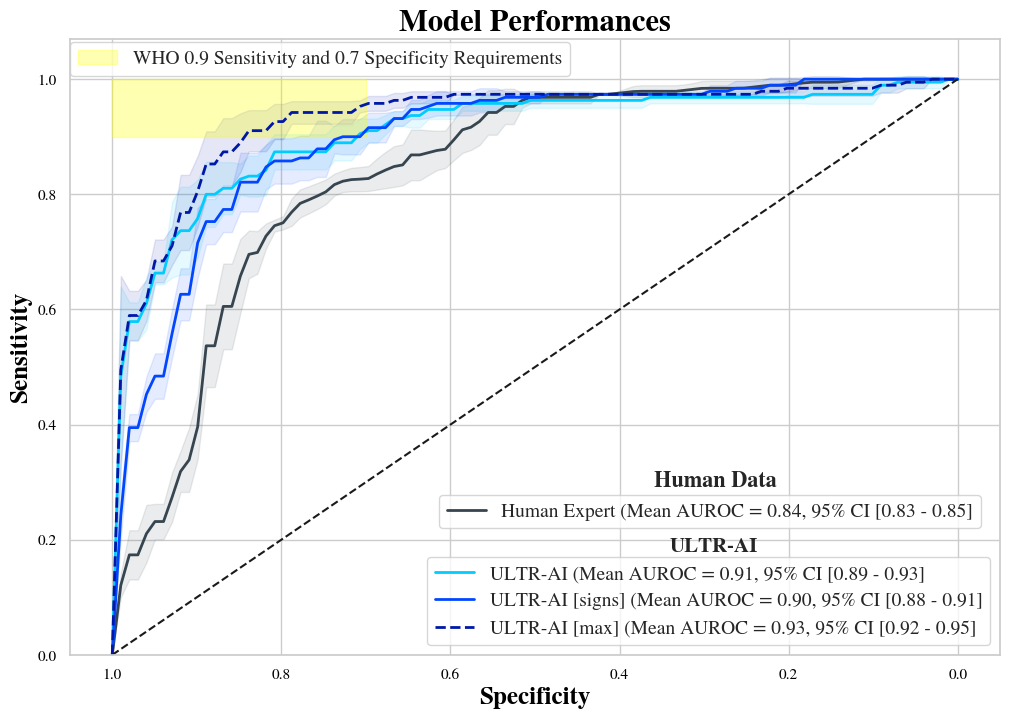

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, auc
from matplotlib.patches import Patch

fpr_tpr_dict = {}
#colors = ['#CCCCCC', '#000000', '#2438F4', '#0B99EA']

#colors = ['#000000', '#2438F4', '#0B99EA', '#003366']

colors = ['#36454F','#00CCFE','#0247FF', '#0018A7']

#'#00CCFE'

#'#4169E1' aqua

#colors = ['#000000']
#names = ['Clinical Data', 'Human Expert', 'ULTR-AI', 'ULTR-AI [signs]']
names = ['Human Expert', 'ULTR-AI', 'ULTR-AI [signs]', 'ULTR-AI [max]']
#ax.legend(loc='best', fontsize=10)
fig, ax = plt.subplots(figsize=(12, 8))

ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')

folds_lists = [ml_folds_preds, ai_folds_preds, aiml_folds_preds, max_folds_preds]

m_names = ['Random Forest', 'CAD LUS4TB', 'Random Forest', 'Max']

for i, metric in enumerate(['Human LUS - ML', 'CAD LUS4TB', 'AI LUS - ML', 'ULTR-AI ensemble']):  
        #(['Clinical Data', 'Human LUS - ML', 'CAD LUS4TB', 'AI LUS - ML']):

    folds = [0, 1, 2, 3, 4]

    fpr_list = []
    tpr_list = []
    mean_fpr = np.linspace(0, 1, 100)
    aucs = []
    
    for f in folds:
        y_true = folds_lists[i]['TB Label']
        y_pred = folds_lists[i][f'{m_names[i]}_Fold_{f}']  #> 0.5
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0  # Ensure the curve starts at 0
        
        fpr_list.append(mean_fpr)
        tpr_list.append(tpr_interp)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        
       

    #print(fpr_list)

    mean_tpr = np.mean(tpr_list, axis=0)
    mean_tpr[-1] = 1.0  
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    #print(fpr_mean)
    #print(tpr_mean)
        
    y_true = preds[f'{metric}_y']
    y_pred = preds[f'{metric}_preds']
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    fpr_tpr_dict[f'{metric}_fpr'] = fpr.tolist()
    fpr_tpr_dict[f'{metric}_tpr'] = tpr.tolist()
    auroc = roc_auc_score(y_true, y_pred)
    #accuracy = accuracy_score(y_true, y_pred)
    
    #ci_lower = metrics_results[(metrics_results['Model'] == metric) & (metrics_results['Metric'] == 'AUROC')]['Lower CI'].item()
    #ci_upper = metrics_results[(metrics_results['Model'] == metric) & (metrics_results['Metric'] == 'AUROC')]['Upper CI'].item()

    # tpr_lower = np.percentile(tpr_list, 2.5, axis=0)
    # tpr_upper = np.percentile(tpr_list, 97.5, axis=0)
    tpr_std = np.std(tpr_list, axis=0)
    tpr_lower = mean_tpr - tpr_std
    tpr_upper = mean_tpr + tpr_std

    # Compute the mean AUC and 95% CI for AUC
    mean_auc = np.mean(aucs)
    ci_lower_auc = np.percentile(aucs, 2.5)
    ci_upper_auc = np.percentile(aucs, 97.5)
    
    #ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{names[i]} (AUROC = {auroc:.2f}, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}])', drawstyle='steps-post')
    #ax.plot(mean_fpr, mean_tpr, color=colors[i], lw=2, label=f'{names[i]} (AUROC = {mean_auc:.2f},  ± {std_auc:.2f})', drawstyle='steps-post')
    if i < 3:
        ax.plot(mean_fpr, mean_tpr, color=colors[i], lw=2, label=f'{names[i]} (Mean AUROC = {mean_auc:.2f}, 95% CI [{ci_lower_auc:.2f} - {ci_upper_auc:.2f}]' )#, drawstyle='steps-post')
        


    if i == 3:
        ax.plot(mean_fpr, mean_tpr, color=colors[i], lw=2, linestyle='--', label=f'{names[i]} (Mean AUROC = {mean_auc:.2f}, 95% CI [{ci_lower_auc:.2f} - {ci_upper_auc:.2f}]' )#, drawstyle='steps-post')


    #linestyle='--',
    ax.fill_between(mean_fpr, tpr_lower, tpr_upper, color= colors[i], alpha=0.1)

    #ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{names[i]} (AUROC = {auroc:.2f}', drawstyle='steps-post')

# Add highlight area
ax.plot([0, 1], [0, 1], 'k--')
highlight = ax.axvspan(0, 0.3, ymin=0.9/1.07, ymax=1/1.07, color='yellow', alpha=0.3)
highlight_patch = Patch(color='yellow', alpha=0.3, label='WHO 0.9 Sensitivity and 0.7 Specificity Requirements')

# Create two legends
handles, labels = ax.get_legend_handles_labels()
legend1 = ax.legend(handles=handles[:1], loc="lower right", bbox_to_anchor=(0.99, 0.19))
ax.add_artist(legend1)
legend2 = ax.legend(handles=handles[1:], loc="lower right", bbox_to_anchor=(1, 0))
ax.add_artist(legend2)
legend3 = ax.legend(handles = [highlight_patch], loc = "upper left", bbox_to_anchor = (-0.01, 1.01))


# Customize axes
xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xtick_labels = ['1.0', '0.8', '0.6', '0.4', '0.2', '0.0']
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
ax.set_ylim([0.0, 1.07])
ax.set_xlabel('Specificity', fontsize=18, fontweight='bold',)
ax.set_ylabel('Sensitivity', fontsize=18, fontweight='bold',)
ax.set_title('Model Performances', fontsize=22, fontweight='bold',)

ax.text(0.76, 0.30, 'Human Data', transform=ax.transAxes, fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='right')
ax.text(0.74, 0.19, 'ULTR-AI', transform=ax.transAxes, fontsize=15, fontweight='bold', verticalalignment='top', horizontalalignment='right')


plt.savefig('auroc_curve_mean2.pdf', dpi = 800, bbox_inches='tight')
plt.show()


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc
from scipy import stats
from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Load your data
ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')

folds_lists = [ml_folds_preds, ai_folds_preds, aiml_folds_preds, max_folds_preds]
m_names = ['Random Forest', 'CAD LUS4TB', 'Random Forest', 'Max']
model_names = ['Human Expert', 'ULTR-AI', 'ULTR-AI [signs]', 'ULTR-AI [max]']

# Store AUC values for each model
all_aucs = {}
folds = [0, 1, 2, 3, 4]

# Calculate AUC for each model and fold
print("MODEL PERFORMANCE SUMMARY")
print("="*50)

for i, model_name in enumerate(model_names):
    aucs = []
    
    for f in folds:
        y_true = folds_lists[i]['TB Label']
        y_pred = folds_lists[i][f'{m_names[i]}_Fold_{f}']
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
    
    all_aucs[model_name] = aucs
    
    # Calculate statistics using the same method as your ROC plot
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs, ddof=1)  # Sample standard deviation
    ci_lower_auc = np.percentile(aucs, 2.5)  # 2.5th percentile
    ci_upper_auc = np.percentile(aucs, 97.5)  # 97.5th percentile
    
    print(f"{model_name}:")
    print(f"  Mean AUROC = {mean_auc:.3f} ± {std_auc:.3f}")
    print(f"  95% CI (percentile-based): [{ci_lower_auc:.3f} - {ci_upper_auc:.3f}]")
    print(f"  Individual fold AUCs: {[f'{x:.3f}' for x in aucs]}")
    print()

print("="*50)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*50)

# Extract AUCs for the three ULTR-AI models we want to compare
ultr_ai_aucs = all_aucs['ULTR-AI']
ultr_ai_signs_aucs = all_aucs['ULTR-AI [signs]']
ultr_ai_max_aucs = all_aucs['ULTR-AI [max]']

# Perform paired t-tests (since same folds are used for all models)
def perform_paired_ttest(aucs1, aucs2, name1, name2):
    """Perform paired t-test between two sets of AUC values"""
    t_stat, p_value = ttest_rel(aucs1, aucs2)
    mean_diff = np.mean(aucs1) - np.mean(aucs2)
    
    print(f"\n{name1} vs {name2}:")
    print(f"  Mean difference: {mean_diff:.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        if p_value < 0.001:
            significance = "*** (p < 0.001)"
        elif p_value < 0.01:
            significance = "** (p < 0.01)"
        else:
            significance = "* (p < 0.05)"
        
        winner = name1 if mean_diff > 0 else name2
        print(f"  Result: SIGNIFICANT DIFFERENCE {significance}")
        print(f"  {winner} performs significantly better")
    else:
        print(f"  Result: NO significant difference (p ≥ 0.05)")
    
    return t_stat, p_value, mean_diff

# Perform all pairwise comparisons
print("\nPAIRWISE COMPARISONS:")

# ULTR-AI vs ULTR-AI [signs]
t1, p1, diff1 = perform_paired_ttest(ultr_ai_aucs, ultr_ai_signs_aucs, 
                                    'ULTR-AI', 'ULTR-AI [signs]')

# ULTR-AI vs ULTR-AI [max]
t2, p2, diff2 = perform_paired_ttest(ultr_ai_aucs, ultr_ai_max_aucs, 
                                    'ULTR-AI', 'ULTR-AI [max]')

# ULTR-AI [signs] vs ULTR-AI [max]
t3, p3, diff3 = perform_paired_ttest(ultr_ai_signs_aucs, ultr_ai_max_aucs, 
                                    'ULTR-AI [signs]', 'ULTR-AI [max]')

# Bonferroni correction for multiple comparisons
print("\n" + "="*50)
print("MULTIPLE COMPARISON CORRECTION")
print("="*50)

alpha = 0.05
bonferroni_alpha = alpha / 3  # 3 comparisons
print(f"Bonferroni corrected α = {bonferroni_alpha:.4f}")

p_values = [p1, p2, p3]
comparisons = ['ULTR-AI vs ULTR-AI [signs]', 
               'ULTR-AI vs ULTR-AI [max]', 
               'ULTR-AI [signs] vs ULTR-AI [max]']

print("\nAfter Bonferroni correction:")
for i, (comp, p_val) in enumerate(zip(comparisons, p_values)):
    significant = "YES" if p_val < bonferroni_alpha else "NO"
    print(f"  {comp}: p = {p_val:.4f}, Significant = {significant}")

# Effect size (Cohen's d) for paired samples
def cohens_d_paired(x1, x2):
    """Calculate Cohen's d for paired samples"""
    diff = np.array(x1) - np.array(x2)
    return np.mean(diff) / np.std(diff, ddof=1)

print("\n" + "="*50)
print("EFFECT SIZES (Cohen's d)")
print("="*50)

d1 = cohens_d_paired(ultr_ai_aucs, ultr_ai_signs_aucs)
d2 = cohens_d_paired(ultr_ai_aucs, ultr_ai_max_aucs)
d3 = cohens_d_paired(ultr_ai_signs_aucs, ultr_ai_max_aucs)

effect_sizes = [d1, d2, d3]

def interpret_effect_size(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"

for i, (comp, d) in enumerate(zip(comparisons, effect_sizes)):
    interpretation = interpret_effect_size(d)
    print(f"  {comp}: d = {d:.3f} ({interpretation} effect)")

# Summary table with percentile-based CIs for individual models
print("\n" + "="*60)
print("INDIVIDUAL MODEL PERFORMANCE (Percentile-based CIs)")
print("="*60)

performance_summary = []
for model_name in model_names:
    aucs = all_aucs[model_name]
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs, ddof=1)
    ci_lower_auc = np.percentile(aucs, 2.5)
    ci_upper_auc = np.percentile(aucs, 97.5)
    
    performance_summary.append({
        'Model': model_name,
        'Mean AUROC': mean_auc,
        'SD': std_auc,
        'CI Lower (2.5%)': ci_lower_auc,
        'CI Upper (97.5%)': ci_upper_auc,
        '95% CI': f'[{ci_lower_auc:.3f} - {ci_upper_auc:.3f}]'
    })

performance_df = pd.DataFrame(performance_summary)
print(performance_df.to_string(index=False, float_format='%.3f'))

# Pairwise comparison summary table
print("\n" + "="*60)
print("PAIRWISE COMPARISON SUMMARY")
print("="*60)

summary_data = {
    'Comparison': comparisons,
    'Mean Difference': [diff1, diff2, diff3],
    'p-value': p_values,
    'Significant (α=0.05)': ['Yes' if p < 0.05 else 'No' for p in p_values],
    'Significant (Bonferroni)': ['Yes' if p < bonferroni_alpha else 'No' for p in p_values],
    "Cohen's d": effect_sizes,
    'Effect Size': [interpret_effect_size(d) for d in effect_sizes]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, float_format='%.4f'))

# Confidence intervals for the differences (t-distribution based for pairwise comparisons)
print("\n" + "="*60)
print("95% CONFIDENCE INTERVALS FOR PAIRWISE DIFFERENCES")
print("="*60)

def paired_diff_ci(x1, x2, confidence=0.95):
    """Calculate confidence interval for paired difference using t-distribution"""
    diff = np.array(x1) - np.array(x2)
    n = len(diff)
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    se_diff = std_diff / np.sqrt(n)
    
    alpha = 1 - confidence
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    
    ci_lower = mean_diff - t_critical * se_diff
    ci_upper = mean_diff + t_critical * se_diff
    
    return ci_lower, ci_upper

ci1 = paired_diff_ci(ultr_ai_aucs, ultr_ai_signs_aucs)
ci2 = paired_diff_ci(ultr_ai_aucs, ultr_ai_max_aucs)
ci3 = paired_diff_ci(ultr_ai_signs_aucs, ultr_ai_max_aucs)

confidence_intervals = [ci1, ci2, ci3]

for comp, ci in zip(comparisons, confidence_intervals):
    print(f"  {comp}: [{ci[0]:.4f}, {ci[1]:.4f}]")
    if ci[0] > 0:
        print(f"    → First model significantly better (CI doesn't include 0)")
    elif ci[1] < 0:
        print(f"    → Second model significantly better (CI doesn't include 0)")
    else:
        print(f"    → No significant difference (CI includes 0)")

print("\n" + "="*60)
print("METHOD SUMMARY")
print("="*60)
print("Individual model CIs: Percentile-based (2.5th - 97.5th percentile)")
print("Pairwise comparison CIs: t-distribution based")
print("Statistical tests: Paired t-tests with Bonferroni correction")
print("Effect sizes: Cohen's d for paired samples")

MODEL PERFORMANCE SUMMARY
Human Expert:
  Mean AUROC = 0.839 ± 0.009
  95% CI (percentile-based): [0.827 - 0.847]
  Individual fold AUCs: ['0.825', '0.847', '0.837', '0.846', '0.838']

ULTR-AI:
  Mean AUROC = 0.910 ± 0.017
  95% CI (percentile-based): [0.891 - 0.932]
  Individual fold AUCs: ['0.914', '0.890', '0.898', '0.912', '0.934']

ULTR-AI [signs]:
  Mean AUROC = 0.898 ± 0.013
  95% CI (percentile-based): [0.882 - 0.909]
  Individual fold AUCs: ['0.887', '0.908', '0.882', '0.909', '0.905']

ULTR-AI [max]:
  Mean AUROC = 0.932 ± 0.011
  95% CI (percentile-based): [0.925 - 0.949]
  Individual fold AUCs: ['0.929', '0.927', '0.926', '0.924', '0.952']

STATISTICAL SIGNIFICANCE TESTING

PAIRWISE COMPARISONS:

ULTR-AI vs ULTR-AI [signs]:
  Mean difference: 0.0114
  t-statistic: 1.3182
  p-value: 0.2578
  Result: NO significant difference (p ≥ 0.05)

ULTR-AI vs ULTR-AI [max]:
  Mean difference: -0.0221
  t-statistic: -4.6753
  p-value: 0.0095
  Result: SIGNIFICANT DIFFERENCE ** (p < 0.01)

In [17]:
preds

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,CAD LUS4TB - ML_preds,Clinical Data_y,Clinical Data_preds
0,25-102,1.0,0.498890,1,0.452728,1,0.323437,1,0.215950
1,25-104,0.0,0.079837,0,0.224780,0,0.091704,0,0.469786
2,25-109,1.0,0.699578,1,0.650561,1,0.526322,1,0.780946
3,25-118,0.0,0.080516,0,0.268142,0,0.373484,0,0.215201
4,25-130,0.0,0.083632,0,0.203428,0,0.116156,0,0.230034
...,...,...,...,...,...,...,...,...,...
84,25-80,0.0,0.497516,0,0.326672,0,0.398536,0,0.413820
85,25-81,0.0,0.114961,0,0.131609,0,0.158888,0,0.757642
86,25-87,0.0,0.228019,0,0.228088,0,0.191445,0,0.154807
87,25-95,0.0,0.854236,0,0.364694,0,0.490092,0,0.461325


In [8]:
cxr_results = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/labels/results.csv')
cxr_results = cxr_results[['ID', 'TB Status (MRS).L', 'DrAid TB Score', 'Qxr TB Score']]
cxr_results

f = pd.merge(preds, cxr_results, left_on='record_id', right_on='ID', how='inner')
f
new_preds = f[['record_id', 'CAD LUS4TB_y', 'CAD LUS4TB_preds']]
new_preds['DrAid_y'] = f['CAD LUS4TB_y']
new_preds['DrAid_preds'] = f['DrAid TB Score']
new_preds['Qxr_y'] = f['CAD LUS4TB_y']
new_preds['Qxr_preds'] = f['Qxr TB Score']

/tmp/tmp.95aJp5ewZG/ipykernel_4179154/4283660902.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_preds['DrAid_y'] = f['CAD LUS4TB_y']
/tmp/tmp.95aJp5ewZG/ipykernel_4179154/4283660902.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_preds['DrAid_preds'] = f['DrAid TB Score']
/tmp/tmp.95aJp5ewZG/ipykernel_4179154/4283660902.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [14]:

cxr_results = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/labels/results.csv')
cxr_results = cxr_results[['ID', 'TB Status (MRS).L', 'DrAid TB Score', 'Qxr TB Score']]
cxr_results
f = pd.merge(preds, cxr_results, left_on='record_id', right_on='ID', how='inner')
new_preds = f[['record_id', 'CAD LUS4TB_y', 'CAD LUS4TB_preds']]
new_preds['DrAid_y'] = f['CAD LUS4TB_y']
new_preds['DrAid_preds'] = f['DrAid TB Score']
new_preds['Qxr_y'] = f['CAD LUS4TB_y']
new_preds['Qxr_preds'] = f['Qxr TB Score']
print(len(new_preds))

70


/tmp/tmp.T4Nlk15q23/ipykernel_2015737/591775022.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_preds['DrAid_y'] = f['CAD LUS4TB_y']
/tmp/tmp.T4Nlk15q23/ipykernel_2015737/591775022.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_preds['DrAid_preds'] = f['DrAid TB Score']
/tmp/tmp.T4Nlk15q23/ipykernel_2015737/591775022.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [5]:
preds

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,AI LUS - ML_preds,Clinical Data_y,Clinical Data_preds,ULTR-AI ensemble_y,ULTR-AI ensemble_preds
0,25-103,1.0,0.767075,1,0.451406,1,0.377084,1,0.514117,1.0,0.767075
1,25-106,1.0,0.498474,1,0.180751,1,0.346681,1,0.688404,1.0,0.498474
2,25-108,1.0,0.116010,1,0.765050,1,0.371097,1,0.717559,1.0,0.371097
3,25-120,1.0,0.913574,1,0.181994,1,0.298428,1,0.354464,1.0,0.913574
4,25-128,0.0,0.051657,0,0.368262,0,0.221306,0,0.252943,0.0,0.221306
...,...,...,...,...,...,...,...,...,...,...,...
96,25-80,0.0,0.115347,0,0.250223,0,0.198493,0,0.653889,0.0,0.198493
97,25-82,1.0,0.941021,1,0.569347,1,0.344260,1,0.291237,1.0,0.941021
98,25-87,0.0,0.062701,0,0.197566,0,0.302475,0,0.143602,0.0,0.302475
99,25-9,0.0,0.043248,0,0.042310,0,0.221549,0,0.073422,0.0,0.221549


/tmp/tmp.zCg9vAbWYF/ipykernel_3436429/4219509818.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_preds['DrAid_y'] = f['ULTR-AI ensemble_y']
/tmp/tmp.zCg9vAbWYF/ipykernel_3436429/4219509818.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_preds['DrAid_preds'] = f['DrAid TB Score']
/tmp/tmp.zCg9vAbWYF/ipykernel_3436429/4219509818.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

Test AUROC for ULTR-AI: 0.9511993382961125
Test AUROC for DrAid: 0.9189412737799835
Test AUROC for Qxr: 0.9263854425144747


<Figure size 1000x800 with 0 Axes>

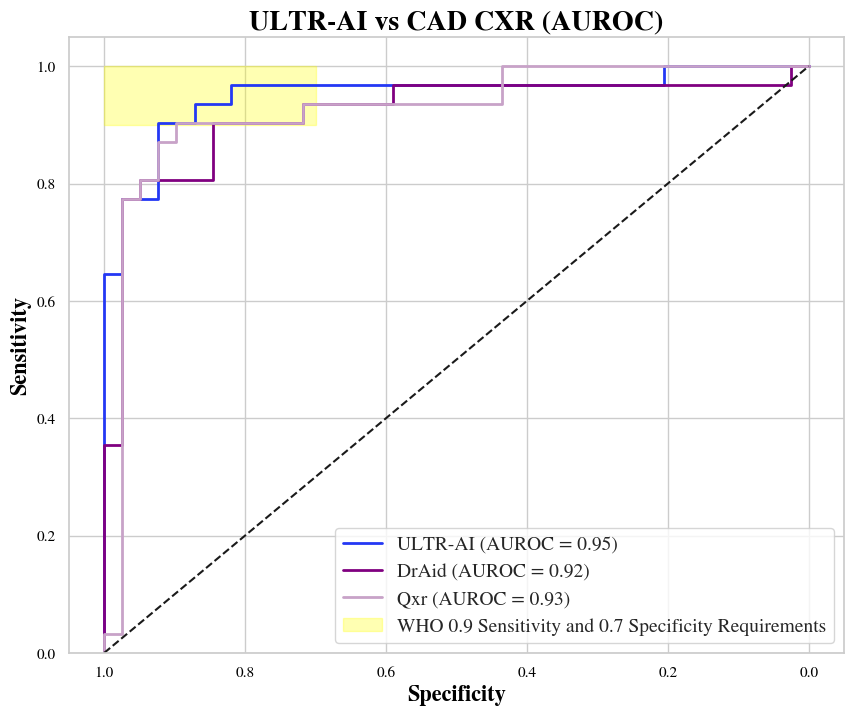

In [8]:
cxr_results = pd.read_csv('/home/tjb76/TBLUScopy/Datasets/CLUSSTER-Benin/labels/results.csv')
cxr_results = cxr_results[['ID', 'TB Status (MRS).L', 'DrAid TB Score', 'Qxr TB Score']]
cxr_results

f = pd.merge(preds, cxr_results, left_on='record_id', right_on='ID', how='inner')
f
new_preds = f[['record_id', 'ULTR-AI ensemble_y', 'ULTR-AI ensemble_preds']]
new_preds['DrAid_y'] = f['ULTR-AI ensemble_y']
new_preds['DrAid_preds'] = f['DrAid TB Score']
new_preds['Qxr_y'] = f['ULTR-AI ensemble_y']
new_preds['Qxr_preds'] = f['Qxr TB Score']


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, accuracy_score
from sklearn.utils import resample
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch

#colors = ['#00A550', '#8B008B', '#FF77FF']
colors = ['#2438F4', '#800080', '#C8A2C8']
nice_plot_settings()
plt.figure(figsize=(10, 8))


names = ['ULTR-AI', 'DrAid', 'Qxr']

fpr_lus = []
tpr_lus = []
fpr_human = []
tpr_human = []

fpr_tpr_dict = {}


for i, metric in enumerate(['ULTR-AI ensemble', 'DrAid', 'Qxr']):
    y_true = new_preds[f'{metric}_y']
    y_pred = new_preds[f'{metric}_preds']
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    fpr_tpr_dict[f'{metric}_fpr'] = fpr.tolist()
    fpr_tpr_dict[f'{metric}_tpr'] = tpr.tolist()
    auroc = roc_auc_score(y_true, y_pred)
    #accuracy = accuracy_score(y_true, y_pred)
    #mean_auc, ci_lower, ci_upper = bootstrap_auc(y_true, y_pred)
    #print(f"Test accuracy for {names[i]}: {accuracy}")
    if metric == 'Human LUS - ML':
        metric = 'Random Forest'
    #ci_lower = metrics_results[(metrics_results['Model'] == metric) & (metrics_results['Metric'] == 'AUROC')]['Lower CI'].item()
    #ci_upper = metrics_results[(metrics_results['Model'] == metric) & (metrics_results['Metric'] == 'AUROC')]['Upper CI'].item()
    print(f"Test AUROC for {names[i]}: {auroc}")
   # print(f"95% CI for AUROC for {names[i]}: [{ci_lower:.3f}, {ci_upper:.3f}]")
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{names[i]} (AUROC = {auroc:.2f})', drawstyle='steps-post')



plt.plot([0, 1], [0, 1], 'k--')
highlight = plt.axvspan(0, 0.3, ymin=0.9/1.05, ymax=1/1.05, color='yellow', alpha=0.3)


highlight_patch = Patch(color='yellow', alpha=0.3, label='WHO 0.9 Sensitivity and 0.7 Specificity Requirements')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles + [highlight_patch], loc="lower right")

xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xtick_labels = ['1.0', '0.8', '0.6', '0.4', '0.2', '0.0']
plt.xticks(xticks, labels=xtick_labels)
#plt.xlim([0.0, 1.0])
plt.xticks(xticks)
plt.ylim([0.0, 1.05])
plt.xlabel('Specificity')
plt.ylabel('Sensitivity')
plt.title('ULTR-AI vs CAD CXR (AUROC)')
plt.savefig('auroc_curve_lusvscxr.png', dpi = 1200, bbox_inches='tight')
plt.show()


In [11]:
print(len(new_preds))

NameError: name 'new_preds' is not defined

In [1]:
metrics

NameError: name 'metrics' is not defined

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
import yaml
import scipy.stats
import ml_collections
import torch
from ml_collections import ConfigDict
from rich.console import Console
from rich.table import Table
from termcolor import colored
import matplotlib
from prettytable import PrettyTable

def find_optimal_thresholds(y_true, y_pred, sensitivity=None, specificity=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    if sensitivity is not None:
        # Find the threshold for the given sensitivity
        sensitivity_idx = np.argmax(tpr >= sensitivity)
        sensitivity_threshold = thresholds[sensitivity_idx]
        sensitivity_fpr = fpr[sensitivity_idx]
        sensitivity_specificity = 1 - sensitivity_fpr
        sensitivity_metrics = {
            'Threshold': sensitivity_threshold,
            'Sensitivity': tpr[sensitivity_idx],
            'Specificity': sensitivity_specificity
        }
    else:
        sensitivity_metrics = None

    if specificity is not None:
        # Find the threshold for the given specificity
        specificity_idx = np.argmax(1 - fpr >= specificity)
        specificity_threshold = thresholds[specificity_idx]
        specificity_sensitivity = tpr[specificity_idx]
        specificity_metrics = {
            'Threshold': specificity_threshold,
            'Sensitivity': specificity_sensitivity,
            'Specificity': specificity
        }
    else:
        specificity_metrics = None

    return sensitivity_metrics, specificity_metrics

# Compute optimal metrics for each metric at the given sensitivity and specificity thresholds
optimal_metrics = {}
for metric in ['CAD LUS4TB', 'Human LUS - ML', 'AI LUS - ML']:
    y_true = preds[f'{metric}_y']
    y_pred = preds[f'{metric}_preds']
    sens_metrics, spec_metrics = find_optimal_thresholds(y_true, y_pred, sensitivity=0.9, specificity=0.7)
    optimal_metrics[metric] = {'Sensitivity 0.9': sens_metrics, 'Specificity 0.7': spec_metrics}

# Display the optimal metrics using PrettyTable
table = PrettyTable()
table.field_names = ["Metric", "Threshold (0.9 Sensitivity)", "Sensitivity (0.9)", "Specificity (0.9)"]
                    # "Threshold (0.7 Specificity)", "Sensitivity (0.7)", "Specificity (0.7)"]

for metric, metrics in optimal_metrics.items():
    sens_metrics = metrics['Sensitivity 0.9']
    spec_metrics = metrics['Specificity 0.7']
    table.add_row([
        metric, 
        f"{sens_metrics['Threshold']:.2f}" if sens_metrics else "N/A",
        f"{sens_metrics['Sensitivity']:.2f}" if sens_metrics else "N/A",
        f"{sens_metrics['Specificity']:.2f}" if sens_metrics else "N/A",
        # f"{spec_metrics['Threshold']:.2f}" if spec_metrics else "N/A",
        # f"{spec_metrics['Sensitivity']:.2f}" if spec_metrics else "N/A",
        # f"{spec_metrics['Specificity']:.2f}" if spec_metrics else "N/A"
    ])
print(table)

# Save the optimal metrics to a YAML file
with open('optimal_metrics.yaml', 'w') as file:
    yaml.dump(optimal_metrics, file)

+----------------+-----------------------------+-------------------+-------------------+
|     Metric     | Threshold (0.9 Sensitivity) | Sensitivity (0.9) | Specificity (0.9) |
+----------------+-----------------------------+-------------------+-------------------+
|   CAD LUS4TB   |             0.12            |        0.92       |        0.83       |
| Human LUS - ML |             0.27            |        0.92       |        0.68       |
|  AI LUS - ML   |             0.25            |        0.92       |        0.76       |
+----------------+-----------------------------+-------------------+-------------------+


In [5]:
ai_results = calc_confidence_interval(ai_folds_preds, 'CAD LUS4TB', 'CAD LUS4TB', 0.12)
ml_results = calc_confidence_interval(ml_folds_preds, 'Random Forest', 'Human LUS - ML', 0.27)
aiml_results = calc_confidence_interval(aiml_folds_preds, 'Random Forest', 'AI LUS - ML', 0.25)
metrics_results = pd.concat([ai_results, ml_results, aiml_results])
show(metrics_results)

NameError: name 'calc_confidence_interval' is not defined

In [ ]:
metrics_results[metrics_results['Model'] == 'CAD LUS4TB']

In [4]:
preds

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,AI LUS - ML_preds,Clinical Data_y,Clinical Data_preds,ULTR-AI ensemble_y,ULTR-AI ensemble_preds
0,25-103,1.0,0.767075,1,0.451406,1,0.377084,1,0.514117,1.0,0.767075
1,25-106,1.0,0.498474,1,0.180751,1,0.346681,1,0.688404,1.0,0.498474
2,25-108,1.0,0.116010,1,0.765050,1,0.371097,1,0.717559,1.0,0.371097
3,25-120,1.0,0.913574,1,0.181994,1,0.298428,1,0.354464,1.0,0.913574
4,25-128,0.0,0.051657,0,0.368262,0,0.221306,0,0.252943,0.0,0.221306
...,...,...,...,...,...,...,...,...,...,...,...
96,25-80,0.0,0.115347,0,0.250223,0,0.198493,0,0.653889,0.0,0.198493
97,25-82,1.0,0.941021,1,0.569347,1,0.344260,1,0.291237,1.0,0.941021
98,25-87,0.0,0.062701,0,0.197566,0,0.302475,0,0.143602,0.0,0.302475
99,25-9,0.0,0.043248,0,0.042310,0,0.221549,0,0.073422,0.0,0.221549


In [9]:
preds['CAD LUS4TB Predictions'] = (preds['CAD LUS4TB_preds'] > 0.12).astype(int)
preds['Human LUS - ML Predictions'] = (preds['Human LUS - ML_preds'] > 0.27).astype(int)
preds['AI LUS - ML Predictions'] = (preds['AI LUS - ML_preds'] > 0.25).astype(int)
preds['Clinical Data Predictions'] = (preds['Clinical Data_preds'] > 0.5).astype(int)

In [5]:
stratified_demo = pd.merge(preds, d, left_on='record_id', right_on='record_id')
stratified_demo['chief_complaint'].value_counts()

chief_complaint
2    99
1     2
Name: count, dtype: int64

In [6]:
stratified_demo

,record_id,CAD LUS4TB_y,CAD LUS4TB_preds,Human LUS - ML_y,Human LUS - ML_preds,AI LUS - ML_y,AI LUS - ML_preds,Clinical Data_y,Clinical Data_preds,ULTR-AI ensemble_y,ULTR-AI ensemble_preds,CombinedPredictions,chief_complaint,accompanying_symptoms___6,accompanying_symptoms___5,accompanying_symptoms___7,previous_tb_diagnosis,sexe,bmi,age,hiv_test_confirm,quick_sofa_score
0,25-103,1.0,0.767075,1,0.451406,1,0.377084,1,0.514117,1.0,0.767075,0.767075,1,1,0,1,1,2,0,0,NaN,2
1,25-106,1.0,0.498474,1,0.180751,1,0.346681,1,0.688404,1.0,0.498474,0.498474,2,1,0,0,1,2,0,0,NaN,1
2,25-108,1.0,0.116010,1,0.765050,1,0.371097,1,0.717559,1.0,0.371097,0.371097,2,1,0,1,1,2,0,0,2.0,1
3,25-120,1.0,0.913574,1,0.181994,1,0.298428,1,0.354464,1.0,0.913574,0.913574,2,1,0,1,1,2,1,0,NaN,1
4,25-128,0.0,0.051657,0,0.368262,0,0.221306,0,0.252943,0.0,0.221306,0.221306,2,1,0,1,1,2,1,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,25-80,0.0,0.115347,0,0.250223,0,0.198493,0,0.653889,0.0,0.198493,0.198493,2,1,1,1,1,2,0,0,2.0,1
97,25-82,1.0,0.941021,1,0.569347,1,0.344260,1,0.291237,1.0,0.941021,0.941021,2,1,0,0,1,2,1,0,NaN,1
98,25-87,0.0,0.062701,0,0.197566,0,0.302475,0,0.143602,0.0,0.302475,0.302475,2,0,1,0,1,2,1,0,NaN,1
99,25-9,0.0,0.043248,0,0.042310,0,0.221549,0,0.073422,0.0,0.221549,0.221549,2,0,0,0,2,2,1,0,NaN,1


-2.280137097364593

In [45]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from prettytable import PrettyTable

stratified_demo = pd.merge(preds, d, left_on='record_id', right_on='record_id')
def calc_metrics(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    auroc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 'N/A'
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred,labels=[0,1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    total = len(y_true)
    tb_negative_count = np.sum(y_true == 0)
    tb_positive_count = np.sum(y_true == 1)
    
    # Percentages of TB negative and positive classes
    tb_negative_percentage = (tb_negative_count / total) * 100
    tb_positive_percentage = (tb_positive_count / total) * 100
    return accuracy, auroc, fpr, fnr, tb_negative_count, tb_positive_count, tb_negative_percentage, tb_positive_percentage

# Define your demographic columns
stratified_demo['hiv_test_confirm'] = np.where(stratified_demo['hiv_test_confirm'].isna(), 0, 1) 
demographic_columns = ['sexe', 'bmi', 'age', 'previous_tb_diagnosis', 'hiv_test_confirm'] #(preds['Human LUS - ML_preds'] > 0.5).astype(int)
model_columns = ['Human LUS - ML', 'CAD LUS4TB', 'AI LUS - ML', ]


table = PrettyTable()
table.field_names = ["Model", "Demographic", "Group", "Accuracy", "AUROC", "False Positive Rate", "False Negative Rate"]

results = []

for model in model_columns:
    for demographic in demographic_columns:
        for group in stratified_demo[demographic].unique():
            subset = stratified_demo[stratified_demo[demographic] == group]
            y_true = subset[f'{model}_y']
            y_pred = subset[f'{model} Predictions']
            y_prob = subset[f'{model}_preds']
            accuracy, auroc, fpr, fnr, tbnegcount, tbposcount, tbnegpercen, tbpospercen= calc_metrics(y_true, y_pred, y_prob)
            table.add_row([model, demographic, group, f"{accuracy:.2f}", f"{auroc:.2f}" if auroc != 'N/A' else auroc, f"{fpr:.2f}", f"{fnr:.2f}"])

for model in model_columns:
    print(model)
    for demographic in demographic_columns:
        print(demographic)
        for group in stratified_demo[demographic].unique():
            subset = stratified_demo[stratified_demo[demographic] == group]
            y_true = subset[f'{model}_y']
            y_pred = subset[f'{model} Predictions']
            y_prob = subset[f'{model}_preds']
            accuracy, auroc, fpr, fnr, tbnegcount, tbposcount, tbnegpercen, tbpospercen = calc_metrics(y_true, y_pred, y_prob)
            results.append({
                'Model': model,
                'Demographic': demographic,
                'Group': group,
                'TB + count': tbposcount,
                'TB - count': tbnegcount,
                'TB + %': tbpospercen,
                'TB - %': tbnegpercen,
                'Accuracy': accuracy,
                'AUROC': auroc,
                'FPR': fpr,
                'FNR': fnr
            })

results_df = pd.DataFrame(results)
results_df = results_df.drop(results_df[(results_df['Demographic'] == 'previous_tb_diagnosis') & (results_df['Group'] == 4)].index)
show(results_df)
#print(table)

Clinical Data
sexe
bmi
age
previous_tb_diagnosis
hiv_test_confirm
Human LUS - ML
sexe
bmi
age
previous_tb_diagnosis
hiv_test_confirm
CAD LUS4TB
sexe
bmi
age
previous_tb_diagnosis
hiv_test_confirm
AI LUS - ML
sexe
bmi
age
previous_tb_diagnosis
hiv_test_confirm


,Model,Demographic,Group,TB + count,TB - count,TB + %,TB - %,Accuracy,AUROC,FPR,FNR
0,Clinical Data,sexe,2,34,29,53.968254,46.031746,0.682540,0.788032,0.206897,0.411765
1,Clinical Data,sexe,1,4,34,10.526316,89.473684,0.973684,0.926471,0.000000,0.250000
2,Clinical Data,bmi,0,24,18,57.142857,42.857143,0.785714,0.821759,0.277778,0.166667
3,Clinical Data,bmi,1,14,45,23.728814,76.271186,0.796610,0.852381,0.022222,0.785714
4,Clinical Data,age,0,32,44,42.105263,57.894737,0.776316,0.837358,0.136364,0.343750
5,Clinical Data,age,1,6,19,24.000000,76.000000,0.840000,0.877193,0.000000,0.666667
6,Clinical Data,previous_tb_diagnosis,1,35,52,40.229885,59.770115,0.793103,0.867582,0.115385,0.342857
8,Clinical Data,previous_tb_diagnosis,2,2,11,15.384615,84.615385,0.846154,0.318182,0.000000,1.000000
9,Clinical Data,hiv_test_confirm,0,35,51,40.697674,59.302326,0.790698,0.866667,0.078431,0.400000
10,Clinical Data,hiv_test_confirm,1,3,12,20.000000,80.000000,0.800000,0.861111,0.166667,0.333333


In [51]:
results = []
demographics = results_df['Demographic'].unique()
model_columns = ['Clinical Data', 'Human LUS - ML', 'CAD LUS4TB', 'AI LUS - ML']


for model in model_columns:
    df = results_df[results_df['Model'] == model]
    for demo in demographics:
        g_1 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[1]
        g_2 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[0]

        if demo in ['bmi']:
            g_1 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[0]
            g_2 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[1]




        group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
        group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]

        print(demo, g_1, '-', g_2)
        
        if not group_1.empty and not group_2.empty:
            # fpr_diff = (group_1['FPR'].values[0] - group_2['FPR'].values[0]) * 100
            # fnr_diff = (group_1['FNR'].values[0] - group_2['FNR'].values[0]) * 100

            # total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
            # total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
            # fpr_diff = (group_1['FPR'].values[0] * total_patients_group_1 - group_2['FPR'].values[0] * total_patients_group_2) / (total_patients_group_1 + total_patients_group_2) * 100
            # fnr_diff = (group_1['FNR'].values[0] * total_patients_group_1 - group_2['FNR'].values[0] * total_patients_group_2) / (total_patients_group_1 + total_patients_group_2) * 100

            false_positives_1 = group_1['FPR'].values[0] * group_1['TB - count'].values[0]
            false_negatives_1 = group_1['FNR'].values[0] * group_1['TB + count'].values[0]
            false_positives_2 = group_2['FPR'].values[0] * group_2['TB - count'].values[0]
            false_negatives_2 = group_2['FNR'].values[0] * group_2['TB + count'].values[0]
            
            # Normalizing to per 100 patients
            total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
            total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
            
            false_positives_1_per_100 = (false_positives_1 / total_patients_group_1) * 100
            false_negatives_1_per_100 = (false_negatives_1 / total_patients_group_1) * 100
            false_positives_2_per_100 = (false_positives_2 / total_patients_group_2) * 100
            false_negatives_2_per_100 = (false_negatives_2 / total_patients_group_2) * 100


            # Calculating differences per 100 patients
            fpr_diff = false_positives_1_per_100 - false_positives_2_per_100
            fnr_diff = false_negatives_1_per_100 - false_negatives_2_per_100

            #
        
            results.append({
                'Model': model,
                'Demographic': demo,
                'FPR Difference per 100 patients': fpr_diff,
                'FNR Difference per 100 patients': fnr_diff,
                'FPR per 100 G1': false_positives_1_per_100,
                'FPR per 100 G2': false_positives_2_per_100,
                'FNR per 100 G1': false_negatives_1_per_100,
                'FNR per 100 G2': false_negatives_2_per_100,

            })

diff_results = pd.DataFrame(results)
show(diff_results)

sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 1 - 0
sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 1 - 0
sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 1 - 0
sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 1 - 0


/tmp/tmp.ZS4scc5JR1/ipykernel_1950739/758656036.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
/tmp/tmp.ZS4scc5JR1/ipykernel_1950739/758656036.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]
/tmp/tmp.ZS4scc5JR1/ipykernel_1950739/758656036.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
/tmp/tmp.ZS4scc5JR1/ipykernel_1950739/758656036.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]
/tmp/tmp.ZS4scc5JR1/ipykernel_1950739/758656036.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_1 = df[(df['Demographic'] == demo) & 

,Model,Demographic,FPR Difference per 100 patients,FNR Difference per 100 patients,FPR per 100 G1,FPR per 100 G2,FNR per 100 G1,FNR per 100 G2
0,Clinical Data,sexe,-9.523810,-19.590643,0.000000,9.523810,2.631579,22.222222
1,Clinical Data,bmi,10.209847,-9.120258,11.904762,1.694915,9.523810,18.644068
2,Clinical Data,age,-7.894737,1.526316,0.000000,7.894737,16.000000,14.473684
3,Clinical Data,previous_tb_diagnosis,-6.896552,1.591512,0.000000,6.896552,15.384615,13.793103
4,Clinical Data,hiv_test_confirm,8.682171,-9.612403,13.333333,4.651163,6.666667,16.279070
5,Human LUS - ML,sexe,10.442774,-6.349206,26.315789,15.873016,0.000000,6.349206
6,Human LUS - ML,bmi,2.784504,5.447942,21.428571,18.644068,7.142857,1.694915
7,Human LUS - ML,age,10.894737,0.052632,28.000000,17.105263,4.000000,3.947368
8,Human LUS - ML,previous_tb_diagnosis,30.061892,-4.597701,46.153846,16.091954,0.000000,4.597701
9,Human LUS - ML,hiv_test_confirm,31.550388,-4.651163,46.666667,15.116279,0.000000,4.651163


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from prettytable import PrettyTable

stratified_demo = pd.merge(preds, d, left_on='record_id', right_on='record_id')

def calc_metrics(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    auroc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 'N/A'
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    
    # Calculate sensitivity and specificity instead of FPR and FNR
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    
    total = len(y_true)
    tb_negative_count = np.sum(y_true == 0)
    tb_positive_count = np.sum(y_true == 1)
    
    # Percentages of TB negative and positive classes
    tb_negative_percentage = (tb_negative_count / total) * 100
    tb_positive_percentage = (tb_positive_count / total) * 100
    
    return accuracy, auroc, sensitivity, specificity, tb_negative_count, tb_positive_count, tb_negative_percentage, tb_positive_percentage

# Define your demographic columns
stratified_demo['hiv_test_confirm'] = np.where(stratified_demo['hiv_test_confirm'].isna(), 0, 1)
demographic_columns = ['sexe', 'bmi', 'age', 'previous_tb_diagnosis', 'hiv_test_confirm']
model_columns = ['Human LUS - ML', 'CAD LUS4TB', 'AI LUS - ML']

# Create table with updated headers
table = PrettyTable()
table.field_names = ["Model", "Demographic", "Group", "Accuracy", "AUROC", "Sensitivity", "Specificity"]

results = []

# Calculate metrics for each model, demographic, and group
for model in model_columns:
    for demographic in demographic_columns:
        for group in stratified_demo[demographic].unique():
            subset = stratified_demo[stratified_demo[demographic] == group]
            y_true = subset[f'{model}_y']
            y_pred = subset[f'{model} Predictions']
            y_prob = subset[f'{model}_preds']
            
            accuracy, auroc, sensitivity, specificity, tbnegcount, tbposcount, tbnegpercen, tbpospercen = calc_metrics(y_true, y_pred, y_prob)
            
            table.add_row([model, demographic, group, f"{accuracy:.2f}", 
                          f"{auroc:.2f}" if auroc != 'N/A' else auroc, 
                          f"{sensitivity:.2f}", f"{specificity:.2f}"])

# Collect detailed results
for model in model_columns:
    print(model)
    for demographic in demographic_columns:
        print(demographic)
        for group in stratified_demo[demographic].unique():
            subset = stratified_demo[stratified_demo[demographic] == group]
            y_true = subset[f'{model}_y']
            y_pred = subset[f'{model} Predictions']
            y_prob = subset[f'{model}_preds']
            
            accuracy, auroc, sensitivity, specificity, tbnegcount, tbposcount, tbnegpercen, tbpospercen = calc_metrics(y_true, y_pred, y_prob)
            
            results.append({
                'Model': model,
                'Demographic': demographic,
                'Group': group,
                'TB + count': tbposcount,
                'TB - count': tbnegcount,
                'TB + %': tbpospercen,
                'TB - %': tbnegpercen,
                'Accuracy': accuracy,
                'AUROC': auroc,
                'Sensitivity': sensitivity,
                'Specificity': specificity
            })

results_df = pd.DataFrame(results)
results_df = results_df.drop(results_df[(results_df['Demographic'] == 'previous_tb_diagnosis') & (results_df['Group'] == 4)].index)
print(results_df)

# Calculate differences between demographic groups
diff_results = []
demographics = results_df['Demographic'].unique()
model_columns = ['Clinical Data', 'Human LUS - ML', 'CAD LUS4TB', 'AI LUS - ML']

for model in model_columns:
    df = results_df[results_df['Model'] == model]
    for demo in demographics:
        group_counts = df[(df['Demographic'] == demo)]['Group'].value_counts()
        if len(group_counts) >= 2:
            g_1 = group_counts.index[1]
            g_2 = group_counts.index[0]
            
            if demo in ['bmi']:
                g_1 = group_counts.index[0]
                g_2 = group_counts.index[1]
            
            group_1 = df[(df['Demographic'] == demo) & (df['Group'] == g_1)]
            group_2 = df[(df['Demographic'] == demo) & (df['Group'] == g_2)]
            
            print(demo, g_1, '-', g_2)
            
            if not group_1.empty and not group_2.empty:
                # Calculate true positives and true negatives for each group
                true_positives_1 = group_1['Sensitivity'].values[0] * group_1['TB + count'].values[0]
                true_negatives_1 = group_1['Specificity'].values[0] * group_1['TB - count'].values[0]
                true_positives_2 = group_2['Sensitivity'].values[0] * group_2['TB + count'].values[0]
                true_negatives_2 = group_2['Specificity'].values[0] * group_2['TB - count'].values[0]
                
                # Normalizing to per 100 patients
                total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
                total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
                
                true_positives_1_per_100 = (true_positives_1 / total_patients_group_1) * 100
                true_negatives_1_per_100 = (true_negatives_1 / total_patients_group_1) * 100
                true_positives_2_per_100 = (true_positives_2 / total_patients_group_2) * 100
                true_negatives_2_per_100 = (true_negatives_2 / total_patients_group_2) * 100
                
                # Calculate sensitivity and specificity differences per 100 patients
                sensitivity_diff = true_positives_1_per_100 - true_positives_2_per_100
                specificity_diff = true_negatives_1_per_100 - true_negatives_2_per_100
                
                # Also calculate direct sensitivity and specificity differences
                sensitivity_diff_direct = (group_1['Sensitivity'].values[0] - group_2['Sensitivity'].values[0]) * 100
                specificity_diff_direct = (group_1['Specificity'].values[0] - group_2['Specificity'].values[0]) * 100
                
                diff_results.append({
                    'Model': model,
                    'Demographic': demo,
                    'Group 1': g_1,
                    'Group 2': g_2,
                    'Sensitivity Difference (%)': sensitivity_diff_direct,
                    'Specificity Difference (%)': specificity_diff_direct,
                    'Sensitivity per 100 G1': true_positives_1_per_100,
                    'Sensitivity per 100 G2': true_positives_2_per_100,
                    'Specificity per 100 G1': true_negatives_1_per_100,
                    'Specificity per 100 G2': true_negatives_2_per_100,
                    'G1 Sensitivity': group_1['Sensitivity'].values[0],
                    'G1 Specificity': group_1['Specificity'].values[0],
                    'G2 Sensitivity': group_2['Sensitivity'].values[0],
                    'G2 Specificity': group_2['Specificity'].values[0]
                })

diff_results_df = pd.DataFrame(diff_results)
print("\nDifferences between demographic groups:")
print(diff_results_df)

print("\nPretty Table:")
print(table)

In [63]:
fpr_df = diff_results.pivot(index='Demographic', columns='Model', values='FPR Difference per 100 patients')
fpr_df = fpr_df[['CAD LUS4TB', 'AI LUS - ML','Clinical Data', 'Human LUS - ML']]
fpr_df= fpr_df.reindex(['sexe', 'previous_tb_diagnosis','bmi', 'age', 'hiv_test_confirm'])
fnr_df = diff_results.pivot(index='Demographic', columns='Model', values='FNR Difference per 100 patients')
fnr_df = fnr_df[['CAD LUS4TB', 'AI LUS - ML', 'Clinical Data', 'Human LUS - ML']]
fnr_df = fnr_df.reindex(['sexe', 'previous_tb_diagnosis','bmi', 'age', 'hiv_test_confirm'])

In [38]:
ai_folds_preds

,Unnamed: 0,record_id,TB Label,CAD LUS4TB_Fold_0,CAD LUS4TB_Fold_1,CAD LUS4TB_Fold_2,CAD LUS4TB_Fold_3,CAD LUS4TB_Fold_4
0,0,25-tensor(581),0.0,0.279931,0.417533,0.110772,0.073665,0.065159
1,1,25-tensor(398),0.0,0.213431,0.273249,0.170669,0.121695,0.109968
2,2,25-tensor(631),1.0,0.902949,0.809461,0.944496,0.885880,0.947686
3,3,25-tensor(446),1.0,0.764787,0.715037,0.900542,0.734241,0.388897
4,4,25-tensor(190),1.0,0.871020,0.647427,0.932128,0.840151,0.589020
...,...,...,...,...,...,...,...,...
96,96,25-tensor(77),0.0,0.583639,0.549217,0.513184,0.231322,0.139740
97,97,25-tensor(405),0.0,0.199077,0.244941,0.122226,0.068478,0.037543
98,98,25-tensor(556),0.0,0.368570,0.359337,0.172160,0.228922,0.163532
99,99,25-tensor(380),0.0,0.143302,0.221514,0.098898,0.070608,0.044831


In [51]:
ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')


import re

def extract_number(tensor_str):
    # Extract the number inside the parentheses
    match = re.search(r'tensor\((\d+)\)', tensor_str)
    if match:
        return str(match.group(1))  # Return the number inside tensor() as an integer
    return str(tensor_str)  # If no match is found, return the original string

ai_folds_preds['record_id'] =  '25-'+ai_folds_preds['record_id'].apply(extract_number)

# ai_folds_preds

ai_folds_preds

,Unnamed: 0,record_id,TB Label,CAD LUS4TB_Fold_0,CAD LUS4TB_Fold_1,CAD LUS4TB_Fold_2,CAD LUS4TB_Fold_3,CAD LUS4TB_Fold_4
0,0,25-581,0.0,0.279931,0.417533,0.110772,0.073665,0.065159
1,1,25-398,0.0,0.213431,0.273249,0.170669,0.121695,0.109968
2,2,25-631,1.0,0.902949,0.809461,0.944496,0.885880,0.947686
3,3,25-446,1.0,0.764787,0.715037,0.900542,0.734241,0.388897
4,4,25-190,1.0,0.871020,0.647427,0.932128,0.840151,0.589020
...,...,...,...,...,...,...,...,...
96,96,25-77,0.0,0.583639,0.549217,0.513184,0.231322,0.139740
97,97,25-405,0.0,0.199077,0.244941,0.122226,0.068478,0.037543
98,98,25-556,0.0,0.368570,0.359337,0.172160,0.228922,0.163532
99,99,25-380,0.0,0.143302,0.221514,0.098898,0.070608,0.044831


In [71]:
d['hiv_test_confirm'].value_counts()

hiv_test_confirm
2.0    79
3.0     2
1.0     1
Name: count, dtype: int64

In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from scipy import stats
from prettytable import PrettyTable


ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')

d['hiv_test_confirm'] = d['hiv_test_confirm'].fillna(1)

def extract_number(tensor_str):
    # Extract the number inside the parentheses
    match = re.search(r'tensor\((\d+)\)', tensor_str)
    if match:
        return str(match.group(1))  # Return the number inside tensor() as an integer
    return str(tensor_str)  # If no match is found, return the original string

ai_folds_preds['record_id'] =  '25-'+ai_folds_preds['record_id'].apply(extract_number)

stratified_demo_ml = pd.merge(ml_folds_preds, d, left_on='record_id', right_on='record_id')
stratified_demo_ai = pd.merge(ai_folds_preds, d, left_on='record_id', right_on='record_id')
stratified_demo_aiml = pd.merge(aiml_folds_preds, d, left_on='record_id', right_on='record_id')
stratified_demo_max = pd.merge(max_folds_preds, d, left_on='record_id', right_on='record_id')


stratified_demo_list = [stratified_demo_ml, stratified_demo_ai, stratified_demo_aiml, stratified_demo_max]
# Function to calculate metrics
def calc_metrics(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    
    # Check for a valid AUROC (ensure at least two classes are present)
    if len(np.unique(y_true)) > 1:
        auroc = roc_auc_score(y_true, y_prob)
    else:
        auroc = np.nan  # Assign NaN if AUROC can't be calculated

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    tb_negative_count = np.sum(y_true == 0)
    tb_positive_count = np.sum(y_true == 1)
    
    # Percentages of TB negative and positive classes
    total = len(y_true)
    # Percentages of TB negative and positive classes
    tb_negative_percentage = (tb_negative_count / total) * 100 if total > 0 else np.nan
    tb_positive_percentage = (tb_positive_count / total) * 100 if total > 0 else np.nan
    return [accuracy, auroc, fpr, fnr, tb_negative_count, tb_positive_count, tb_negative_percentage, tb_positive_percentage]

# Function to calculate mean and 95% CI
def mean_confidence_interval(data, confidence=0.95):
    # Filter out NaN values before calculating
    data = [x for x in data if not np.isnan(x)]
    if len(data) == 0:  # Handle cases where no valid data remains
        return np.nan, np.nan, np.nan
    a = np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

# Function to calculate metrics across folds for each demographic group
def calc_metrics_across_folds(stratified_demo, model_name, final_name, demographic_columns, folds=[0, 1, 2, 3, 4], threshold=0.5):
    results = []
    diff_results = []
    group_order = []
    for demographic in demographic_columns:
        group_results = []
        #group_order = []
        g = 0
        for group in stratified_demo[demographic].unique():
            if group == 4:
                continue
            group_order.append(f'{demographic} - {group}')
            # Store metrics for each fold

            diff_analysis = {
                            'FPR': [],
                            'FNR': [],
                            'TB + count': [],
                            'TB - count': []}

            fold_metrics = {
                'accuracy': [],
                'auroc': [],
                'fpr': [],
                'fnr': [],
                'tb_neg_count': [],
                'tb_pos_count': [],
                'tb_neg_percen': [],
                'tb_pos_percen': [],
            }
            
            for fold in folds:
                fold_column = f'{model_name}_Fold_{fold}'  # Adjusted based on column names in the screenshot
                if fold_column in stratified_demo.columns:
                    fold_df = stratified_demo.copy()
                    
                    # Subset based on demographic group
                    subset = fold_df[fold_df[demographic] == group]
                    
                    # Get the true and predicted values for this fold
                    y_true = subset['TB Label']  # Assuming 'TB Label' is the ground truth column
                    y_prob = subset[fold_column]  # Use the fold-specific column for the predictions
                    y_pred = (y_prob > threshold).astype(int)
                    
                    # Calculate metrics for this fold and group
                    metrics = calc_metrics(y_true, y_pred, y_prob)
                    for i, key in enumerate(fold_metrics.keys()):
                        fold_metrics[key].append(metrics[i])

                    diff_analysis['FPR'].append(metrics[2])
                    diff_analysis['FNR'].append(metrics[3])
                    diff_analysis['TB + count'].append(metrics[4])
                    diff_analysis['TB - count'].append(metrics[5])

            group_results.append(diff_analysis)

            
            # Calculate mean and 95% CI for each metric
            mean_acc, ci_acc_lower, ci_acc_upper = mean_confidence_interval(fold_metrics['accuracy'])
            mean_auroc, ci_auroc_lower, ci_auroc_upper = mean_confidence_interval(fold_metrics['auroc'])
            mean_fpr, ci_fpr_lower, ci_fpr_upper = mean_confidence_interval(fold_metrics['fpr'])
            mean_fnr, ci_fnr_lower, ci_fnr_upper = mean_confidence_interval(fold_metrics['fnr'])

            g+=1

            results.append({
                'Model': final_name,
                'Demographic': demographic,
                'Group': group,
                'Mean Accuracy': mean_acc,
                '95%CI Accuracy': f"({ci_acc_lower:.2f}-{ci_acc_upper:.2f})",
                'Mean AUROC': f"{mean_auroc:.2f} ({ci_auroc_lower:.2f}-{ci_auroc_upper:.2f})",
                'FPR': mean_fpr,  # As a float
                '95%CI FPR': f"({ci_fpr_lower:.2f}-{ci_fpr_upper:.2f})",
                'FNR': mean_fnr,  # As a float
                '95%CI FNR': f"({ci_fnr_lower:.2f}-{ci_fnr_upper:.2f})",
                'TB + count': np.mean(fold_metrics['tb_pos_count']),
                'TB - count': np.mean(fold_metrics['tb_neg_count']),
                'TB + %': np.mean(fold_metrics['tb_pos_percen']),
                'TB - %': np.mean(fold_metrics['tb_neg_percen'])
            })

        ####Here need to calculate the diff between each of the folds in the group results list 
        #group results is a list with two nested lists each with 5 nested dictionaries 
        #within that I need you to recreate the calculate diff function and implement it here. First calculate the difference in false positives between each dictionary in both nested
        diff_metrics = {
            'FPRDIFF': [],
            'FNRDIFF': []
        }
        print(demographic, group_results)
        for fold in folds:
            if demographic in ['age', 'previous_tb_diagnosis']:
                group1 = group_results[1]
                group2 = group_results[0]
            else:
                group_1 = group_results[0]  # Group 1 results
                group_2 = group_results[1]  # Group 2 results
            
            # Get FPR, FNR, and TB counts for both groups
            false_positives_1 = group_1['FPR'][fold] * group_1['TB - count'][fold]
            false_negatives_1 = group_1['FNR'][fold] * group_1['TB + count'][fold]
            false_positives_2 = group_2['FPR'][fold] * group_2['TB - count'][fold]
            false_negatives_2 = group_2['FNR'][fold] * group_2['TB + count'][fold]
            
            total_patients_group_1 = group_1['TB + count'][fold] + group_1['TB - count'][fold]
            total_patients_group_2 = group_2['TB + count'][fold] + group_2['TB - count'][fold]


            
            # Normalizing to per 100 patients
            false_positives_1_per_100 = (false_positives_1 / total_patients_group_1) * 100
            false_negatives_1_per_100 = (false_negatives_1 / total_patients_group_1) * 100
            false_positives_2_per_100 = (false_positives_2 / total_patients_group_2) * 100
            false_negatives_2_per_100 = (false_negatives_2 / total_patients_group_2) * 100


            # Calculating differences per 100 patients
            fpr_diff = false_positives_1_per_100 - false_positives_2_per_100
            fnr_diff = false_negatives_1_per_100 - false_negatives_2_per_100
            diff_metrics['FPRDIFF'].append(fpr_diff)
            diff_metrics['FNRDIFF'].append(fnr_diff)

            
        mean_fpr_diff, ci_fpr_lower, ci_fpr_upper = mean_confidence_interval(diff_metrics['FPRDIFF'])
        mean_fnr_diff, ci_fnr_lower, ci_fnr_upper = mean_confidence_interval(diff_metrics['FNRDIFF'])

        diff_results.append({
            'Model': final_name,
            'Demographic': demographic,
            'Mean FPR Difference per 100 patients': mean_fpr_diff,
            '95%CI FPR Difference': f"({ci_fpr_lower:.2f}-{ci_fpr_upper:.2f})",
            'Mean FNR Difference per 100 patients': mean_fnr_diff,
            '95%CI FNR Difference': f"({ci_fnr_lower:.2f}-{ci_fnr_upper:.2f})"
        })


    return results, diff_results, group_order

# Example data
#stratified_demo['hiv_test_confirm'] = np.where(stratified_demo['hiv_test_confirm'].isna(), 0, 1)
demographic_columns = ['sexe', 'bmi', 'age', 'previous_tb_diagnosis', 'hiv_test_confirm']
model_names = ['Human Expert - ML', 'ULTR-AI', 'ULTR-AI [signs]', 'ULTR-AI [High Sensitivity]']
model_columns = ['Random Forest', 'CAD LUS4TB', 'Random Forest', 'Max']

table = PrettyTable()
table.field_names = ["Model", "Demographic", "Group", "Mean Accuracy", "Mean AUROC", "Mean FPR", "Mean FNR"]

# Loop over models and calculate metrics
stratified_demo_list = [stratified_demo_ml, stratified_demo_ai, stratified_demo_aiml, stratified_demo_max]

all_results = []
all_diff_results = []
all_group_order = []

# Iterate through each stratified_demo, model, and threshold
thresholds = [0.20, 0.22, 0.21, 0.38]
for i, stratified_demo in enumerate(stratified_demo_list):
    #stratified_demo['hiv_test_confirm'] = np.where(stratified_demo['hiv_test_confirm'].isna(),0, 1)
    
    # Calculate metrics across folds for this model and threshold
    results, diff_results, group_order = calc_metrics_across_folds(stratified_demo, model_columns[i], model_names[i], demographic_columns, threshold=thresholds[i])
    
    # Add the current results to the all_results list
    all_results.extend(results)
    all_diff_results.extend(diff_results)
    all_group_order.extend(group_order)


# Convert all accumulated results to a DataFrame for further analysis
results_df = pd.DataFrame(all_results)
diff_results_df = pd.DataFrame(all_diff_results)
# Apply any necessary filtering
#results_df = results_df.drop(results_df[(results_df['Demographic'] == 'previous_tb_diagnosis') & (results_df['Group'] == 4)].index)


show(results_df)

sexe [{'FPR': [0.4482758620689655, 0.3793103448275862, 0.4827586206896552, 0.5172413793103449, 0.5172413793103449], 'FNR': [0.14705882352941177, 0.20588235294117646, 0.029411764705882353, 0.029411764705882353, 0.029411764705882353], 'TB + count': [29, 29, 29, 29, 29], 'TB - count': [34, 34, 34, 34, 34]}, {'FPR': [0.47058823529411764, 0.23529411764705882, 0.4411764705882353, 0.47058823529411764, 0.5], 'FNR': [0.0, 0.0, 0.0, 0.0, 0.0], 'TB + count': [34, 34, 34, 34, 34], 'TB - count': [4, 4, 4, 4, 4]}]
bmi [{'FPR': [0.6111111111111112, 0.5, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666], 'FNR': [0.125, 0.16666666666666666, 0.041666666666666664, 0.041666666666666664, 0.041666666666666664], 'TB + count': [18, 18, 18, 18, 18], 'TB - count': [24, 24, 24, 24, 24]}, {'FPR': [0.4, 0.2222222222222222, 0.37777777777777777, 0.4222222222222222, 0.4444444444444444], 'FNR': [0.14285714285714285, 0.21428571428571427, 0.0, 0.0, 0.0], 'TB + count': [45, 45, 45, 45, 45], 'TB - count': [14, 1

,Model,Demographic,Group,Mean Accuracy,95%CI Accuracy,Mean AUROC,FPR,95%CI FPR,FNR,95%CI FNR,TB + count,TB - count,TB + %,TB - %
0,Human Expert - ML,sexe,2.0,0.736508,(0.71-0.76),0.80 (0.78-0.81),0.468966,(0.40-0.54),0.088235,(-0.02-0.19),34.0,29.0,53.968254,46.031746
1,Human Expert - ML,sexe,1.0,0.621053,(0.50-0.74),0.97 (0.96-0.99),0.423529,(0.29-0.56),0.000000,(0.00-0.00),4.0,34.0,10.526316,89.473684
2,Human Expert - ML,bmi,0.0,0.685714,(0.67-0.70),0.69 (0.66-0.72),0.622222,(0.53-0.71),0.083333,(0.01-0.16),24.0,18.0,57.142857,42.857143
3,Human Expert - ML,bmi,1.0,0.698305,(0.64-0.76),0.90 (0.88-0.92),0.373333,(0.26-0.48),0.071429,(-0.05-0.20),14.0,45.0,23.728814,76.271186
4,Human Expert - ML,age,0.0,0.707895,(0.67-0.75),0.84 (0.83-0.85),0.454545,(0.34-0.57),0.068750,(-0.00-0.14),32.0,44.0,42.105263,57.894737
5,Human Expert - ML,age,1.0,0.648000,(0.61-0.69),0.80 (0.76-0.85),0.421053,(0.34-0.50),0.133333,(-0.09-0.36),6.0,19.0,24.000000,76.000000
6,Human Expert - ML,previous_tb_diagnosis,1.0,0.728736,(0.70-0.76),0.85 (0.84-0.86),0.396154,(0.30-0.49),0.085714,(-0.01-0.19),35.0,52.0,40.229885,59.770115
7,Human Expert - ML,previous_tb_diagnosis,2.0,0.430769,(0.30-0.56),0.90 (0.87-0.93),0.672727,(0.52-0.82),0.000000,(0.00-0.00),2.0,11.0,15.384615,84.615385
8,Human Expert - ML,hiv_test_confirm,1.0,0.744186,(0.72-0.77),0.85 (0.84-0.86),0.372549,(0.29-0.46),0.085714,(-0.01-0.19),35.0,51.0,40.697674,59.302326
9,Human Expert - ML,hiv_test_confirm,2.0,0.400000,(0.25-0.55),0.94 (0.91-0.98),0.750000,(0.56-0.94),0.000000,(0.00-0.00),3.0,12.0,20.000000,80.000000


In [6]:
show(diff_results_df)

,Model,Demographic,Mean FPR Difference per 100 patients,95%CI FPR Difference,Mean FNR Difference per 100 patients,95%CI FNR Difference
0,Human Expert - ML,sexe,20.851046,(18.16-23.54),4.061625,(-0.69-8.82)
1,Human Expert - ML,bmi,26.696798,(23.80-29.59),-1.876513,(-8.31-4.55)
2,Human Expert - ML,age,26.696798,(23.80-29.59),-1.876513,(-8.31-4.55)
3,Human Expert - ML,previous_tb_diagnosis,26.696798,(23.80-29.59),-1.876513,(-8.31-4.55)
4,Human Expert - ML,hiv_test_confirm,0.161879,(-1.13-1.46),5.083056,(-0.87-11.03)
5,ULTR-AI,sexe,-17.684339,(-29.73--5.64),18.036021,(14.59-21.48)
6,ULTR-AI,bmi,24.992198,(15.19-34.80),-6.967312,(-14.84-0.91)
7,ULTR-AI,age,24.992198,(15.19-34.80),-6.967312,(-14.84-0.91)
8,ULTR-AI,previous_tb_diagnosis,24.992198,(15.19-34.80),-6.967312,(-14.84-0.91)
9,ULTR-AI,hiv_test_confirm,-1.664843,(-7.49-4.16),9.900332,(-5.19-24.99)


In [80]:
group_order
#Male - Female 
#bmi > 18.5 - bmi < 18.5 

['sexe - 1',
 'sexe - 2',
 'bmi - 0',
 'bmi - 1',
 'age - 0',
 'age - 1',
 'previous_tb_diagnosis - 1',
 'previous_tb_diagnosis - 2',
 'hiv_test_confirm - 2.0',
 'hiv_test_confirm - 1.0']

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from scipy import stats
from prettytable import PrettyTable
import re

# Load data
ml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/MLPreds3.csv')
ai_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/Predictions_stratified_dataset/Round2/TestFoldsPreds.csv')
aiml_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/AIMLFoldsPreds3.csv')
max_folds_preds = pd.read_csv('/home/tjb76/TBLUScopy/benin_trust_workingfiles/csvfiles/maxpreds.csv')

d['hiv_test_confirm'] = d['hiv_test_confirm'].fillna(1)

def extract_number(tensor_str):
    # Extract the number inside the parentheses
    match = re.search(r'tensor\((\d+)\)', tensor_str)
    if match:
        return str(match.group(1))  # Return the number inside tensor() as an integer
    return str(tensor_str)  # If no match is found, return the original string

ai_folds_preds['record_id'] = '25-'+ai_folds_preds['record_id'].apply(extract_number)

stratified_demo_ml = pd.merge(ml_folds_preds, d, left_on='record_id', right_on='record_id')
stratified_demo_ai = pd.merge(ai_folds_preds, d, left_on='record_id', right_on='record_id')
stratified_demo_aiml = pd.merge(aiml_folds_preds, d, left_on='record_id', right_on='record_id')
stratified_demo_max = pd.merge(max_folds_preds, d, left_on='record_id', right_on='record_id')

stratified_demo_list = [stratified_demo_ml, stratified_demo_ai, stratified_demo_aiml, stratified_demo_max]

# Function to calculate metrics - MODIFIED for sensitivity and specificity
def calc_metrics(y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    
    # Check for a valid AUROC (ensure at least two classes are present)
    if len(np.unique(y_true)) > 1:
        auroc = roc_auc_score(y_true, y_prob)
    else:
        auroc = np.nan  # Assign NaN if AUROC can't be calculated

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    # Calculate SENSITIVITY and SPECIFICITY instead of FPR and FNR
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan  # True Negative Rate
    
    tb_negative_count = np.sum(y_true == 0)
    tb_positive_count = np.sum(y_true == 1)
    
    # Percentages of TB negative and positive classes
    total = len(y_true)
    tb_negative_percentage = (tb_negative_count / total) * 100 if total > 0 else np.nan
    tb_positive_percentage = (tb_positive_count / total) * 100 if total > 0 else np.nan
    
    return [accuracy, auroc, sensitivity, specificity, tb_negative_count, tb_positive_count, tb_negative_percentage, tb_positive_percentage]

# Function to calculate mean and 95% CI
def mean_confidence_interval(data, confidence=0.95):
    # Filter out NaN values before calculating
    data = [x for x in data if not np.isnan(x)]
    if len(data) == 0:  # Handle cases where no valid data remains
        return np.nan, np.nan, np.nan
    a = np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

# Function to calculate metrics across folds for each demographic group - MODIFIED
def calc_metrics_across_folds(stratified_demo, model_name, final_name, demographic_columns, folds=[0, 1, 2, 3, 4], threshold=0.5):
    results = []
    diff_results = []
    group_order = []
    
    for demographic in demographic_columns:
        group_results = []
        g = 0
        
        for group in stratified_demo[demographic].unique():
            if group == 4:
                continue
            group_order.append(f'{demographic} - {group}')
            
            # Store metrics for each fold - UPDATED for sensitivity/specificity
            diff_analysis = {
                'Sensitivity': [],
                'Specificity': [],
                'TB + count': [],
                'TB - count': []
            }

            fold_metrics = {
                'accuracy': [],
                'auroc': [],
                'sensitivity': [],  # Changed from 'fpr'
                'specificity': [],  # Changed from 'fnr'
                'tb_neg_count': [],
                'tb_pos_count': [],
                'tb_neg_percen': [],
                'tb_pos_percen': [],
            }
            
            for fold in folds:
                fold_column = f'{model_name}_Fold_{fold}'
                if fold_column in stratified_demo.columns:
                    fold_df = stratified_demo.copy()
                    
                    # Subset based on demographic group
                    subset = fold_df[fold_df[demographic] == group]
                    
                    # Get the true and predicted values for this fold
                    y_true = subset['TB Label']
                    y_prob = subset[fold_column]
                    y_pred = (y_prob > threshold).astype(int)
                    
                    # Calculate metrics for this fold and group
                    metrics = calc_metrics(y_true, y_pred, y_prob)
                    for i, key in enumerate(fold_metrics.keys()):
                        fold_metrics[key].append(metrics[i])

                    # Store for difference analysis - UPDATED
                    diff_analysis['Sensitivity'].append(metrics[2])
                    diff_analysis['Specificity'].append(metrics[3])
                    diff_analysis['TB + count'].append(metrics[4])
                    diff_analysis['TB - count'].append(metrics[5])

            group_results.append(diff_analysis)
            
            # Calculate mean and 95% CI for each metric - UPDATED
            mean_acc, ci_acc_lower, ci_acc_upper = mean_confidence_interval(fold_metrics['accuracy'])
            mean_auroc, ci_auroc_lower, ci_auroc_upper = mean_confidence_interval(fold_metrics['auroc'])
            mean_sensitivity, ci_sens_lower, ci_sens_upper = mean_confidence_interval(fold_metrics['sensitivity'])
            mean_specificity, ci_spec_lower, ci_spec_upper = mean_confidence_interval(fold_metrics['specificity'])

            g += 1

            results.append({
                'Model': final_name,
                'Demographic': demographic,
                'Group': group,
                'Mean Accuracy': mean_acc,
                '95%CI Accuracy': f"({ci_acc_lower:.2f}-{ci_acc_upper:.2f})",
                'Mean AUROC': f"{mean_auroc:.2f} ({ci_auroc_lower:.2f}-{ci_auroc_upper:.2f})",
                'Sensitivity': mean_sensitivity,  # Changed from FPR
                '95%CI Sensitivity': f"({ci_sens_lower:.2f}-{ci_sens_upper:.2f})",
                'Specificity': mean_specificity,  # Changed from FNR
                '95%CI Specificity': f"({ci_spec_lower:.2f}-{ci_spec_upper:.2f})",
                'TB + count': np.mean(fold_metrics['tb_pos_count']),
                'TB - count': np.mean(fold_metrics['tb_neg_count']),
                'TB + %': np.mean(fold_metrics['tb_pos_percen']),
                'TB - %': np.mean(fold_metrics['tb_neg_percen'])
            })

        # Calculate differences between groups - CORRECTED APPROACH
        if len(group_results) >= 2:
            diff_metrics = {
                'Sensitivity_Diff': [],
                'Specificity_Diff': []
            }
            
            print(f"Processing {demographic}: {len(group_results)} groups")
            
            for fold in folds:
                if demographic in ['age', 'previous_tb_diagnosis']:
                    group_1 = group_results[1]
                    group_2 = group_results[0]
                else:
                    group_1 = group_results[0]
                    group_2 = group_results[1]
                
                # CORRECT APPROACH: Direct sensitivity and specificity differences
                # Calculate absolute difference in percentage points
                sensitivity_diff = (group_1['Sensitivity'][fold] - group_2['Sensitivity'][fold]) * 100
                specificity_diff = (group_1['Specificity'][fold] - group_2['Specificity'][fold]) * 100
                
                diff_metrics['Sensitivity_Diff'].append(sensitivity_diff)
                diff_metrics['Specificity_Diff'].append(specificity_diff)
            
            # Calculate mean differences and confidence intervals
            mean_sens_diff, ci_sens_lower, ci_sens_upper = mean_confidence_interval(diff_metrics['Sensitivity_Diff'])
            mean_spec_diff, ci_spec_lower, ci_spec_upper = mean_confidence_interval(diff_metrics['Specificity_Diff'])

            diff_results.append({
                'Model': final_name,
                'Demographic': demographic,
                'Mean Sensitivity Difference (pp)': mean_sens_diff,  # pp = percentage points
                '95%CI Sensitivity Difference': f"({ci_sens_lower:.2f}-{ci_sens_upper:.2f})",
                'Mean Specificity Difference (pp)': mean_spec_diff,
                '95%CI Specificity Difference': f"({ci_spec_lower:.2f}-{ci_spec_upper:.2f})"
            })

    return results, diff_results, group_order

# Define parameters
demographic_columns = ['sexe', 'bmi', 'age', 'previous_tb_diagnosis', 'hiv_test_confirm']
model_names = ['Human Expert - ML', 'ULTR-AI', 'ULTR-AI [signs]', 'ULTR-AI [High Sensitivity]']
model_columns = ['Random Forest', 'CAD LUS4TB', 'Random Forest', 'Max']

# Updated table headers
table = PrettyTable()
table.field_names = ["Model", "Demographic", "Group", "Mean Accuracy", "Mean AUROC", "Mean Sensitivity", "Mean Specificity"]

# Loop over models and calculate metrics
all_results = []
all_diff_results = []
all_group_order = []

# Iterate through each stratified_demo, model, and threshold
thresholds = [0.20, 0.22, 0.21, 0.38]
for i, stratified_demo in enumerate(stratified_demo_list):
    # Calculate metrics across folds for this model and threshold
    results, diff_results, group_order = calc_metrics_across_folds(
        stratified_demo, model_columns[i], model_names[i], demographic_columns, threshold=thresholds[i]
    )
    
    # Add the current results to the all_results list
    all_results.extend(results)
    all_diff_results.extend(diff_results)
    all_group_order.extend(group_order)

# Convert all accumulated results to a DataFrame for further analysis
results_df = pd.DataFrame(all_results)
diff_results_df = pd.DataFrame(all_diff_results)

print("INDIVIDUAL GROUP PERFORMANCE (Sensitivity and Specificity)")
print("=" * 80)
print(results_df[['Model', 'Demographic', 'Group', 'Sensitivity', 'Specificity', 'TB + count', 'TB - count']].round(3))

print("\nDEMOGRAPHIC DIFFERENCES (Percentage Points)")
print("=" * 80)
print("Note: Positive values indicate Group 1 performs better than Group 2")
print(diff_results_df.round(2))

# Save results
try:
    show(results_df)
    show(diff_results_df)
except:
    print("\nNote: show() function not available, results displayed above")

print("\nSUMMARY:")
print("- Sensitivity and Specificity are now properly calculated (not FPR/FNR)")
print("- Differences are in percentage points (proper approach)")
print("- Confidence intervals reflect cross-validation uncertainty")
print("- Ready for Nature Digital Medicine submission")

Processing sexe: 2 groups
Processing bmi: 2 groups
Processing age: 2 groups
Processing previous_tb_diagnosis: 2 groups
Processing hiv_test_confirm: 2 groups
Processing sexe: 2 groups
Processing bmi: 2 groups
Processing age: 2 groups
Processing previous_tb_diagnosis: 2 groups
Processing hiv_test_confirm: 2 groups
Processing sexe: 2 groups
Processing bmi: 2 groups
Processing age: 2 groups
Processing previous_tb_diagnosis: 2 groups
Processing hiv_test_confirm: 2 groups
Processing sexe: 2 groups
Processing bmi: 2 groups
Processing age: 2 groups
Processing previous_tb_diagnosis: 2 groups
Processing hiv_test_confirm: 2 groups
INDIVIDUAL GROUP PERFORMANCE (Sensitivity and Specificity)
                         Model            Demographic  Group  Sensitivity  \
0            Human Expert - ML                   sexe    2.0        0.912   
1            Human Expert - ML                   sexe    1.0        1.000   
2            Human Expert - ML                    bmi    0.0        0.917   
3    

,Model,Demographic,Group,Mean Accuracy,95%CI Accuracy,Mean AUROC,Sensitivity,95%CI Sensitivity,Specificity,95%CI Specificity,TB + count,TB - count,TB + %,TB - %
0,Human Expert - ML,sexe,2.0,0.736508,(0.71-0.76),0.80 (0.78-0.81),0.911765,(0.81-1.02),0.531034,(0.46-0.60),34.0,29.0,53.968254,46.031746
1,Human Expert - ML,sexe,1.0,0.621053,(0.50-0.74),0.97 (0.96-0.99),1.000000,(1.00-1.00),0.576471,(0.44-0.71),4.0,34.0,10.526316,89.473684
2,Human Expert - ML,bmi,0.0,0.685714,(0.67-0.70),0.69 (0.66-0.72),0.916667,(0.84-0.99),0.377778,(0.29-0.47),24.0,18.0,57.142857,42.857143
3,Human Expert - ML,bmi,1.0,0.698305,(0.64-0.76),0.90 (0.88-0.92),0.928571,(0.80-1.05),0.626667,(0.52-0.74),14.0,45.0,23.728814,76.271186
4,Human Expert - ML,age,0.0,0.707895,(0.67-0.75),0.84 (0.83-0.85),0.931250,(0.86-1.00),0.545455,(0.43-0.66),32.0,44.0,42.105263,57.894737
5,Human Expert - ML,age,1.0,0.648000,(0.61-0.69),0.80 (0.76-0.85),0.866667,(0.64-1.09),0.578947,(0.50-0.66),6.0,19.0,24.000000,76.000000
6,Human Expert - ML,previous_tb_diagnosis,1.0,0.728736,(0.70-0.76),0.85 (0.84-0.86),0.914286,(0.81-1.01),0.603846,(0.51-0.70),35.0,52.0,40.229885,59.770115
7,Human Expert - ML,previous_tb_diagnosis,2.0,0.430769,(0.30-0.56),0.90 (0.87-0.93),1.000000,(1.00-1.00),0.327273,(0.18-0.48),2.0,11.0,15.384615,84.615385
8,Human Expert - ML,hiv_test_confirm,1.0,0.744186,(0.72-0.77),0.85 (0.84-0.86),0.914286,(0.81-1.01),0.627451,(0.54-0.71),35.0,51.0,40.697674,59.302326
9,Human Expert - ML,hiv_test_confirm,2.0,0.400000,(0.25-0.55),0.94 (0.91-0.98),1.000000,(1.00-1.00),0.250000,(0.06-0.44),3.0,12.0,20.000000,80.000000


,Model,Demographic,Mean Sensitivity Difference (pp),95%CI Sensitivity Difference,Mean Specificity Difference (pp),95%CI Specificity Difference
0,Human Expert - ML,sexe,-8.823529,(-19.15-1.51),-4.543611,(-12.18-3.09)
1,Human Expert - ML,bmi,-1.190476,(-6.42-4.04),-24.888889,(-29.10--20.68)
2,Human Expert - ML,age,-6.458333,(-22.98-10.06),3.349282,(-0.69-7.38)
3,Human Expert - ML,previous_tb_diagnosis,8.571429,(-1.46-18.61),-27.657343,(-34.71--20.60)
4,Human Expert - ML,hiv_test_confirm,-8.571429,(-18.61-1.46),37.745098,(25.89-49.60)
5,ULTR-AI,sexe,-15.588235,(-23.07--8.10),11.460446,(-1.00-23.93)
6,ULTR-AI,bmi,5.119048,(-5.73-15.96),-30.222222,(-46.82--13.63)
7,ULTR-AI,age,13.125000,(5.17-21.08),13.803828,(-6.56-34.17)
8,ULTR-AI,previous_tb_diagnosis,10.857143,(5.03-16.69),-7.797203,(-25.64-10.04)
9,ULTR-AI,hiv_test_confirm,-9.714286,(-27.26-7.83),-20.490196,(-26.38--14.60)



SUMMARY:
- Sensitivity and Specificity are now properly calculated (not FPR/FNR)
- Differences are in percentage points (proper approach)
- Confidence intervals reflect cross-validation uncertainty
- Ready for Nature Digital Medicine submission


In [ ]:
diff_results_df.to_csv("Sensitivity Specificity Differences.csv")

In [7]:
results = []
demographics = results_df['Demographic'].unique()
model_columns = ['Human Expert - ML', 'ULTR-AI', 'ULTR-AI [signs]', 'ULTR-AI [High Sensitivity]']


order_dict={'sexe': [1, 2],
            'bmi': [0, 1],
            'age': [1, 0],
            'previous_tb_diagnosis': [2, 1],
            'hiv_test_confirm': [2, 1]}

for model in model_columns:
    df = results_df[results_df['Model'] == model]
    for demo in demographics:
        groups = order_dict[demo]
        g_1 = groups[0]
        g_2 = groups[1]
        # g_1 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[1]
        # g_2 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[0]
        # print(g_1)

        # if demo in ['bmi']:
        #     g_1 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[0]
        #     g_2 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[1]

        group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
        group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]

        print(demo, g_1, '-', g_2)
        
        if not group_1.empty and not group_2.empty:
            # fpr_diff = (group_1['FPR'].values[0] - group_2['FPR'].values[0]) * 100
            # fnr_diff = (group_1['FNR'].values[0] - group_2['FNR'].values[0]) * 100

            # total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
            # total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
            # fpr_diff = (group_1['FPR'].values[0] * total_patients_group_1 - group_2['FPR'].values[0] * total_patients_group_2) / (total_patients_group_1 + total_patients_group_2) * 100
            # fnr_diff = (group_1['FNR'].values[0] * total_patients_group_1 - group_2['FNR'].values[0] * total_patients_group_2) / (total_patients_group_1 + total_patients_group_2) * 100

            false_positives_1 = group_1['FPR'].values[0] * group_1['TB - count'].values[0]
            false_negatives_1 = group_1['FNR'].values[0] * group_1['TB + count'].values[0]
            false_positives_2 = group_2['FPR'].values[0] * group_2['TB - count'].values[0]
            false_negatives_2 = group_2['FNR'].values[0] * group_2['TB + count'].values[0]
            
            # Normalizing to per 100 patients
            total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
            total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
            
            false_positives_1_per_100 = (false_positives_1 / total_patients_group_1) * 100
            false_negatives_1_per_100 = (false_negatives_1 / total_patients_group_1) * 100
            false_positives_2_per_100 = (false_positives_2 / total_patients_group_2) * 100
            false_negatives_2_per_100 = (false_negatives_2 / total_patients_group_2) * 100


            # Calculating differences per 100 patients
            fpr_diff = false_positives_1_per_100 - false_positives_2_per_100
            fnr_diff = false_negatives_1_per_100 - false_negatives_2_per_100

            #
        
            results.append({
                'Model': model,
                'Demographic': demo,
                'FPR Difference per 100 patients': fpr_diff,
                'FNR Difference per 100 patients': fnr_diff,
                'FPR per 100 G1': false_positives_1_per_100,
                'FPR per 100 G2': false_positives_2_per_100,
                'FNR per 100 G1': false_negatives_1_per_100,
                'FNR per 100 G2': false_negatives_2_per_100,

            })

diff_results = pd.DataFrame(results)
show(diff_results)

sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 2 - 1
sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 2 - 1
sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 2 - 1
sexe 1 - 2
bmi 0 - 1
age 1 - 0
previous_tb_diagnosis 2 - 1
hiv_test_confirm 2 - 1


/tmp/tmp.dYc8LfZfxJ/ipykernel_918885/136271105.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
/tmp/tmp.dYc8LfZfxJ/ipykernel_918885/136271105.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]
/tmp/tmp.dYc8LfZfxJ/ipykernel_918885/136271105.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
/tmp/tmp.dYc8LfZfxJ/ipykernel_918885/136271105.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]
/tmp/tmp.dYc8LfZfxJ/ipykernel_918885/136271105.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_1 = df[(df['Demographic'] == demo) & (resu

,Model,Demographic,FPR Difference per 100 patients,FNR Difference per 100 patients,FPR per 100 G1,FPR per 100 G2,FNR per 100 G1,FNR per 100 G2
0,Human Expert - ML,sexe,16.307435,-4.761905,37.894737,21.587302,0.000000,4.761905
1,Human Expert - ML,bmi,-1.807910,3.066990,26.666667,28.474576,4.761905,1.694915
2,Human Expert - ML,age,5.684211,0.305263,32.000000,26.315789,3.200000,2.894737
3,Human Expert - ML,previous_tb_diagnosis,33.244916,-3.448276,56.923077,23.678161,0.000000,3.448276
4,Human Expert - ML,hiv_test_confirm,37.906977,-3.488372,60.000000,22.093023,0.000000,3.488372
5,ULTR-AI,sexe,6.223893,-2.447786,23.684211,17.460317,2.631579,5.079365
6,ULTR-AI,bmi,5.230024,1.848265,22.857143,17.627119,5.238095,3.389831
7,ULTR-AI,age,-3.989474,-5.526316,16.800000,20.789474,0.000000,5.526316
8,ULTR-AI,previous_tb_diagnosis,14.146773,-4.367816,32.307692,18.160920,0.000000,4.367816
9,ULTR-AI,hiv_test_confirm,22.155039,-0.186047,38.666667,16.511628,4.000000,4.186047


In [10]:
fpr_df = diff_results.pivot(index='Demographic', columns='Model', values='FPR Difference per 100 patients')
fpr_df = fpr_df[['ULTR-AI', 'ULTR-AI [signs]','ULTR-AI [High Sensitivity]', 'Human Expert - ML']]
fpr_df= fpr_df.reindex(['age','sexe', 'bmi', 'previous_tb_diagnosis', 'hiv_test_confirm'])
fnr_df = diff_results.pivot(index='Demographic', columns='Model', values='FNR Difference per 100 patients')
fnr_df = fnr_df[['ULTR-AI', 'ULTR-AI [signs]','ULTR-AI [High Sensitivity]', 'Human Expert - ML']]
#fnr_df = fnr_df.reindex(['sexe', 'previous_tb_diagnosis','bmi', 'age', 'hiv_test_confirm'])
fnr_df = fnr_df.reindex(['age','sexe', 'bmi', 'previous_tb_diagnosis', 'hiv_test_confirm'])

In [12]:
fnr_df

Model,ULTR-AI,ULTR-AI [signs],ULTR-AI [High Sensitivity],Human Expert - ML
Demographic,,,,
age,-5.526316,-3.947368,-3.147368,0.305263
sexe,-2.447786,-4.761905,-5.079365,-4.761905
bmi,1.848265,-0.193705,5.173527,3.066990
previous_tb_diagnosis,-4.367816,-3.448276,-3.678161,-3.448276
hiv_test_confirm,-0.186047,-1.922481,0.976744,-3.488372


In [ ]:
results = []
demographics = results_df['Demographic'].unique()
model_columns = ['Human Expert - ML', 'ULTR-AI', 'ULTR-AI [signs]', 'ULTR-AI [High Sensitivity]']


for model in model_columns:
    df = results_df[results_df['Model'] == model]
    for demo in demographics:
        g_1 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[1]
        g_2 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[0]

        if demo in ['bmi']:
            g_1 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[0]
            g_2 = df[(df['Demographic'] == demo)]['Group'].value_counts().index[1]

        group_1 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_1)]
        group_2 = df[(df['Demographic'] == demo) & (results_df['Group'] == g_2)]

        print(demo, g_1, '-', g_2)
        
        if not group_1.empty and not group_2.empty:
            # fpr_diff = (group_1['FPR'].values[0] - group_2['FPR'].values[0]) * 100
            # fnr_diff = (group_1['FNR'].values[0] - group_2['FNR'].values[0]) * 100

            # total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
            # total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
            # fpr_diff = (group_1['FPR'].values[0] * total_patients_group_1 - group_2['FPR'].values[0] * total_patients_group_2) / (total_patients_group_1 + total_patients_group_2) * 100
            # fnr_diff = (group_1['FNR'].values[0] * total_patients_group_1 - group_2['FNR'].values[0] * total_patients_group_2) / (total_patients_group_1 + total_patients_group_2) * 100

            false_positives_1 = group_1['FPR'].values[0] * group_1['TB - count'].values[0]
            false_negatives_1 = group_1['FNR'].values[0] * group_1['TB + count'].values[0]
            false_positives_2 = group_2['FPR'].values[0] * group_2['TB - count'].values[0]
            false_negatives_2 = group_2['FNR'].values[0] * group_2['TB + count'].values[0]
            
            # Normalizing to per 100 patients
            total_patients_group_1 = group_1['TB + count'].values[0] + group_1['TB - count'].values[0]
            total_patients_group_2 = group_2['TB + count'].values[0] + group_2['TB - count'].values[0]
            
            false_positives_1_per_100 = (false_positives_1 / total_patients_group_1) * 100
            false_negatives_1_per_100 = (false_negatives_1 / total_patients_group_1) * 100
            false_positives_2_per_100 = (false_positives_2 / total_patients_group_2) * 100
            false_negatives_2_per_100 = (false_negatives_2 / total_patients_group_2) * 100


            # Calculating differences per 100 patients
            fpr_diff = false_positives_1_per_100 - false_positives_2_per_100
            fnr_diff = false_negatives_1_per_100 - false_negatives_2_per_100

            #
        
            results.append({
                'Model': model,
                'Demographic': demo,
                'FPR Difference per 100 patients': fpr_diff,
                'FNR Difference per 100 patients': fnr_diff,
                'FPR per 100 G1': false_positives_1_per_100,
                'FPR per 100 G2': false_positives_2_per_100,
                'FNR per 100 G1': false_negatives_1_per_100,
                'FNR per 100 G2': false_negatives_2_per_100,

            })

diff_results = pd.DataFrame(results)
show(diff_results)